In [1]:
from data import AttentionPolicy
from state import State, vectorize, tokenize
from data import load_games

In [2]:
%load_ext autoreload
%autoreload 1

In [41]:
import torch
from data import models
import state

model = AttentionPolicy(*models["small"])
# w = torch.load("./model/medium/100k_20.pth", weights_only=True)
w = torch.load("./model/small/100k_20.pth", weights_only=True)
w = {k: v for k, v in w.items() if "mask" not in k}
model.load_state_dict(w, strict=False) # terrible value network!

_IncompatibleKeys(missing_keys=['blocks.0.mask', 'blocks.1.mask', 'blocks.2.mask', 'blocks.3.mask', 'blocks.4.mask'], unexpected_keys=[])

In [42]:
import chess
import matplotlib.pyplot as plt
import dtypes
from IPython.display import SVG, display

def anal(fen, turn: chess.Color, prev_action: dtypes.Action=None, return_svg=False, ground_truth=None):
    state = State.from_fen(fen, turn)
    x = state.serialize(prev_action=prev_action)
    x = torch.tensor(x).unsqueeze(0)
    prob = model(x).squeeze(0)
    tok = prob.argmax(dim=1).tolist()
    print([tokenize(token) for token in tok[-5:]])
    legal_action = state.get_legel_actions()
    legal_tok_dist = prob[-1].softmax(dim=0)[legal_action]
    sorted_index_legal_tok_dist = torch.argsort(legal_tok_dist, descending=True)
    sorted_legal_action = [legal_action[index] for index in sorted_index_legal_tok_dist]
    top_5_action = sorted_legal_action[:5]
    print(f"Cumprob of legal actions: {legal_tok_dist.sum()}")
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.bar([tokenize(i) for i in sorted_legal_action], legal_tok_dist[sorted_index_legal_tok_dist].tolist())
    ax.set_title(fen)
    colors = ["#0000cccc"]*5
    if prev_action is not None:
        top_5_action.append(prev_action)
        colors.append("#000000")
    svg_arrows = State.svg_arrows(top_5_action, colors)
    if ground_truth is not None:
        svg_arrows.extend(State.svg_arrows([ground_truth], ["#cc0000cc"]))
    print(svg_arrows)
    if return_svg:
        return state.render(svg_arrows)
    else:
        return display(SVG(state.render(svg_arrows)))

['<white_king>', 'e2e4', '<me>', '<black_turn>', 'e7e5']
Cumprob of legal actions: 0.9966851472854614
[Arrow(E7, E5, color='#0000cccc'), Arrow(D7, D5, color='#0000cccc'), Arrow(E7, E6, color='#0000cccc'), Arrow(F7, F5, color='#0000cccc'), Arrow(C7, C5, color='#0000cccc'), Arrow(E2, E4, color='#000000'), Arrow(E7, E5, color='#cc0000cc')]


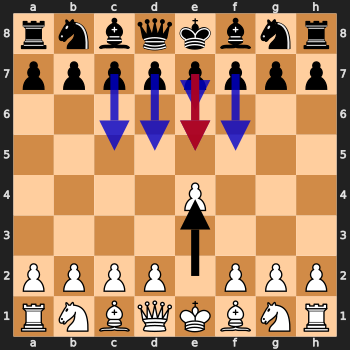

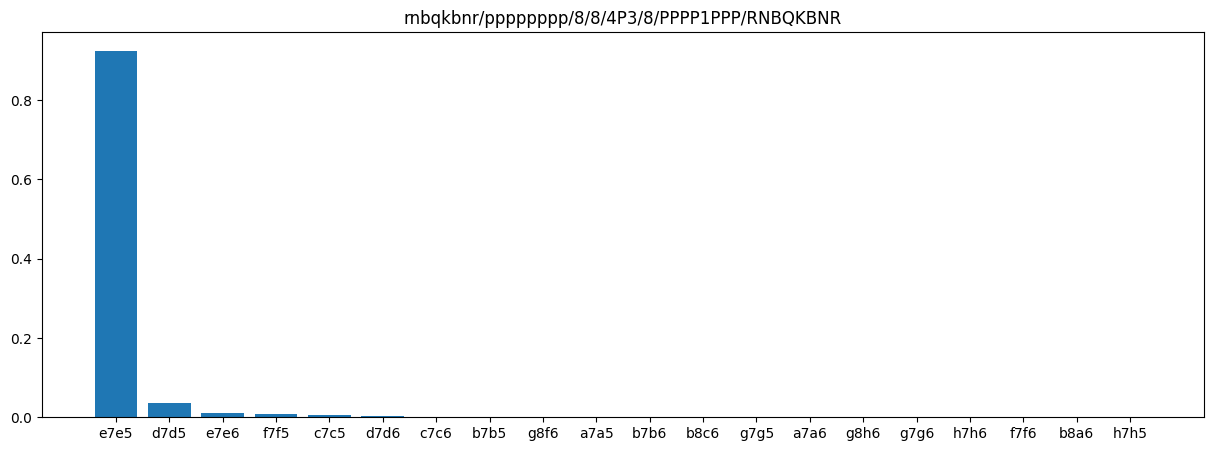

In [43]:
after_e2e4 = "rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR"
anal(after_e2e4, chess.BLACK, vectorize("e2e4"), ground_truth=vectorize("e7e5"))

['<white_king>', 'f8c5', '<me>', '<white_turn>', 'd2d4']
Cumprob of legal actions: 0.5891226530075073
[Arrow(D2, D4, color='#0000cccc'), Arrow(C2, C3, color='#0000cccc'), Arrow(B2, B4, color='#0000cccc'), Arrow(B1, C3, color='#0000cccc'), Arrow(C4, B3, color='#0000cccc'), Arrow(F7, F5, color='#000000')]


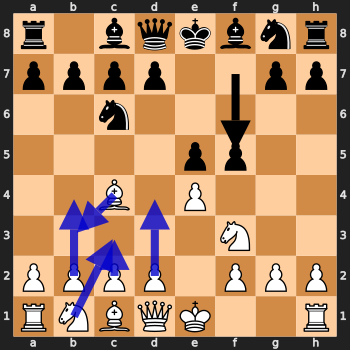

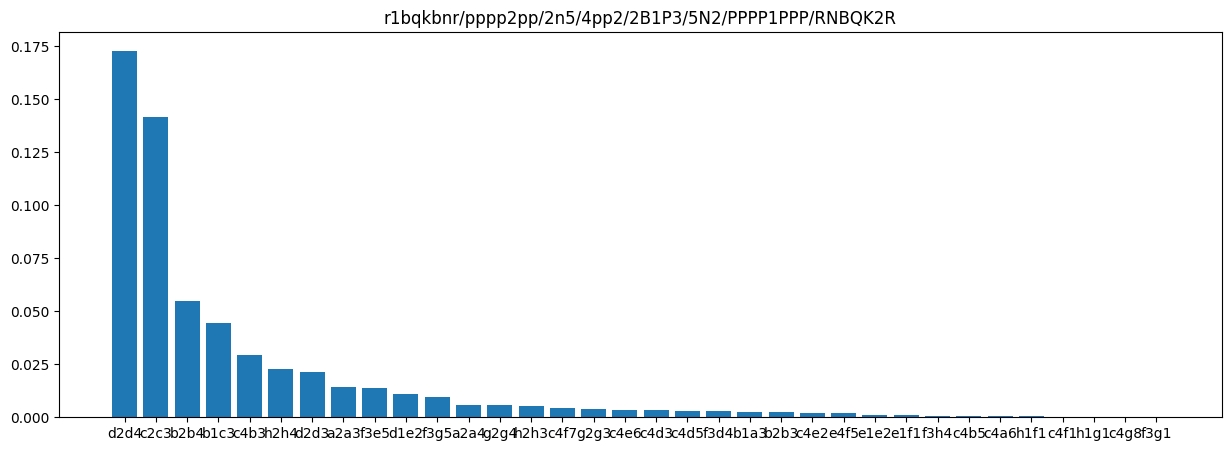

In [44]:
kingside_white_castling_possible = "r1bqkbnr/pppp2pp/2n5/4pp2/2B1P3/5N2/PPPP1PPP/RNBQK2R"
anal(kingside_white_castling_possible, chess.WHITE, vectorize("f7f5"))

['<white_king>', 'b8c6', '<me>', '<white_turn>', 'd2d4']
Cumprob of legal actions: 0.844957709312439
[Arrow(D2, D4, color='#0000cccc'), Arrow(F1, C4, color='#0000cccc'), Arrow(B2, B4, color='#0000cccc'), Arrow(C2, C4, color='#0000cccc'), Arrow(C2, C3, color='#0000cccc'), Arrow(D8, G5, color='#000000')]


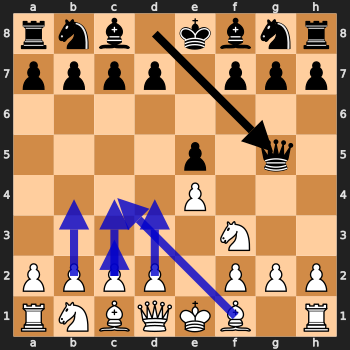

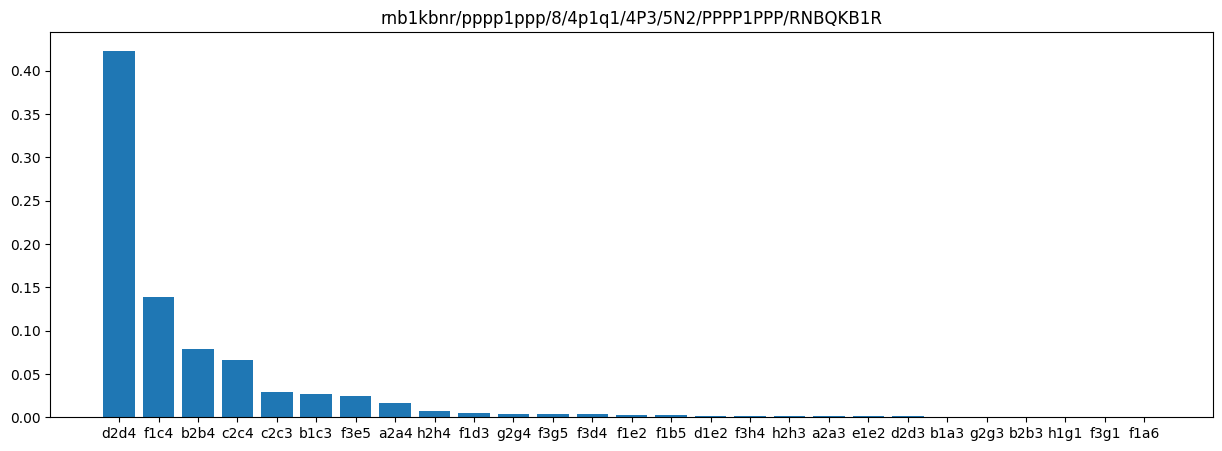

In [45]:
anal("rnb1kbnr/pppp1ppp/8/4p1q1/4P3/5N2/PPPP1PPP/RNBQKB1R", chess.WHITE, vectorize("d8g5"))

['<black_king>', '<black_queen>', '<opponent>', '<black_turn>', 'd7d6']
Cumprob of legal actions: 0.8707348108291626
[Arrow(D7, D6, color='#0000cccc'), Arrow(D7, D5, color='#0000cccc'), Arrow(A7, A5, color='#0000cccc'), Arrow(F7, F5, color='#0000cccc'), Arrow(F8, C5, color='#0000cccc')]


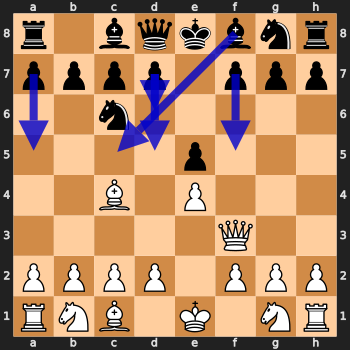

['<opponent>', 'f1c4', '<me>', '<black_turn>', 'f8c5']
Cumprob of legal actions: 0.6626256108283997
[Arrow(F8, C5, color='#0000cccc'), Arrow(D7, D6, color='#0000cccc'), Arrow(G8, F6, color='#0000cccc'), Arrow(D7, D5, color='#0000cccc'), Arrow(F8, B4, color='#0000cccc'), Arrow(D1, F3, color='#000000')]


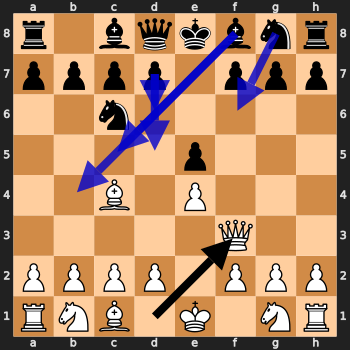

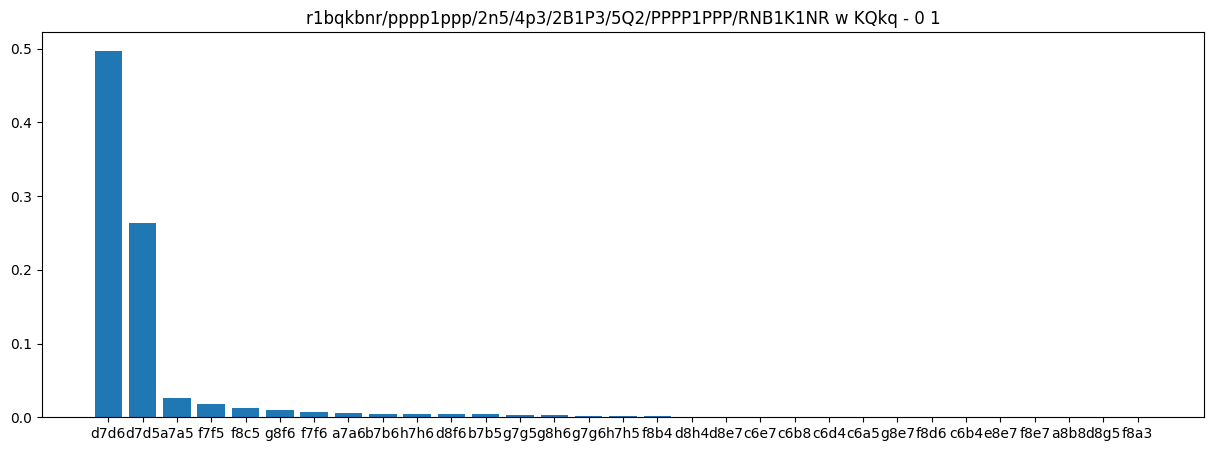

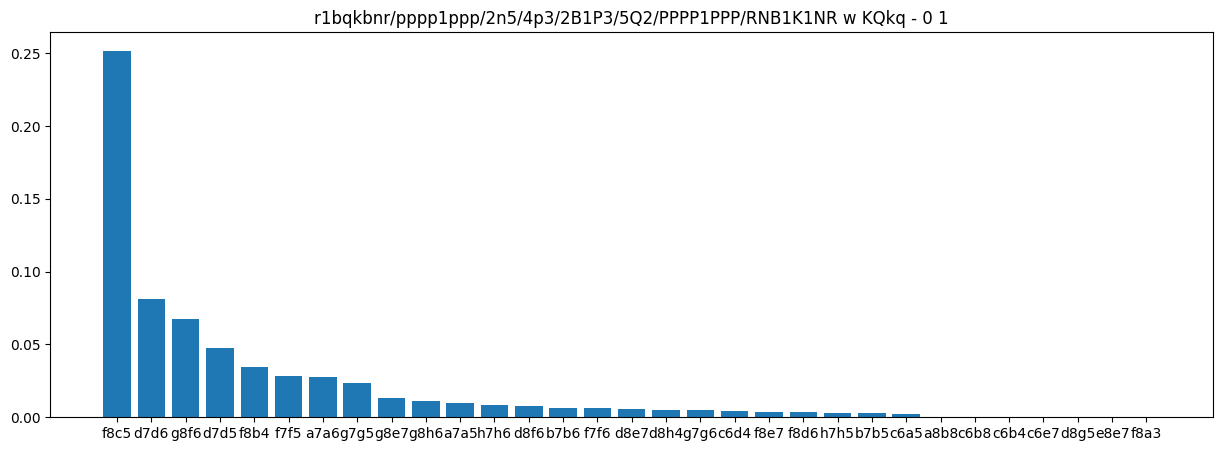

In [46]:
anal("r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPP1PPP/RNB1K1NR w KQkq - 0 1", chess.BLACK)
anal("r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPP1PPP/RNB1K1NR w KQkq - 0 1", chess.BLACK, vectorize("d1f3"))

In [47]:
(board:=chess.Board()).set_fen("r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPPNPPP/RNB1K2R b KQkq - 1 1")

board.has_kingside_castling_rights(chess.WHITE)
board.has_kingside_castling_rights(chess.BLACK)

True

In [48]:
from functools import cache

@cache
def load(save_path=None):
    path = "./data/DATABASE4U.pgn"
    mode = "sequence" # or cnn
    vectors, actions, attention_masks,results = load_games(path, mode, max_length=160, save_path=save_path)

    vectors, results = vectors[:100], results[:100]
    return vectors, results

In [49]:
vectors, results = load(save_path=f"./data/processed/database4u_withturn_sequence.npz")

--- Loaded cache from ./data/processed/database4u_withturn_sequence.npz ---


rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR<legal_moves>g1h3g1f3b1c3b1a3h2h3g2g3f2f3e2e3d2d3c2c3b2b3a2a3h2h4g2g4f2f4e2e4d2d4c2c4b2b4a2a4<white_king><white_queen><black_king><black_queen><me><white_turn>e2e4<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
['b2b4', 'a2a4', '<white_king>', '<white_turn>', 'e2e4']
Cumprob of legal actions: 0.9925408959388733
[Arrow(E2, E4, color='#0000cccc'), Arrow(D2, D4, color='#0000cccc'), Arrow(C2, C4, color='#0000cccc'), Arrow(F2, F4, color='#0000cccc'), Arrow(G1, F3, color='#0000cccc'), Arrow(E2, E4, color='#cc0000cc')]
rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR<legal_moves>g8h6g8f6b8c6b8a6h7h6g7g6f7f6e7e6d7d6c7c6b7b6a7a6h7h5g7g5f7f5e7e5d7d5c7c5b7b5a7a5<white_king><white_queen><black_king><black_queen><op

/var/folders/wk/7qx0rv3n58lbj8js8tqzyn8m0000gn/T/ipykernel_10498/1397937363.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(15, 5))


[Arrow(A1, E1, color='#0000cccc'), Arrow(F1, E1, color='#0000cccc'), Arrow(C3, D5, color='#0000cccc'), Arrow(G1, H1, color='#0000cccc'), Arrow(H2, H3, color='#0000cccc'), Arrow(F8, D8, color='#000000'), Arrow(D2, C2, color='#cc0000cc')]
r2r2k1/1bqn1pbp/p1p2np1/4p3/p1P1P3/2N1BP2/1PQ1BNPP/R4RK1<legal_moves>g8h8g8f8d8f8d8e8d8c8d8b8a8c8a8b8a8a7g7h8g7f8g7h6d7f8d7b8d7b6d7c5c7c8c7b8c7d6c7b6c7a5b7c8f6e8f6h5f6d5f6g4f6e4h7h6g6g5c6c5a6a5a4a3h7h5<opponent>d2c2<me><black_turn>a4a3<pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
['<opponent>', 'e1g1', '<me>', '<black_turn>', 'd6e5']
Cumprob of legal actions: 0.13619889318943024
[Arrow(F6, D5, color='#0000cccc'), Arrow(F6, E4, color='#0000cccc'), Arrow(H7, H6, color='#0000cccc'), Arrow(F6, G4, color='#0000cccc'), Arrow(C7, B6, color='#0000cccc'), Arrow(D2, C2, c

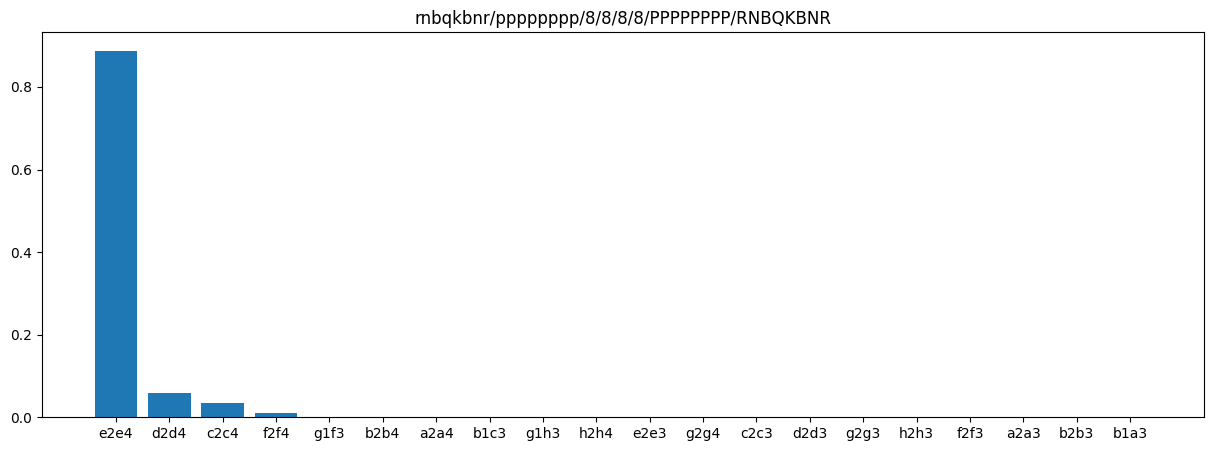

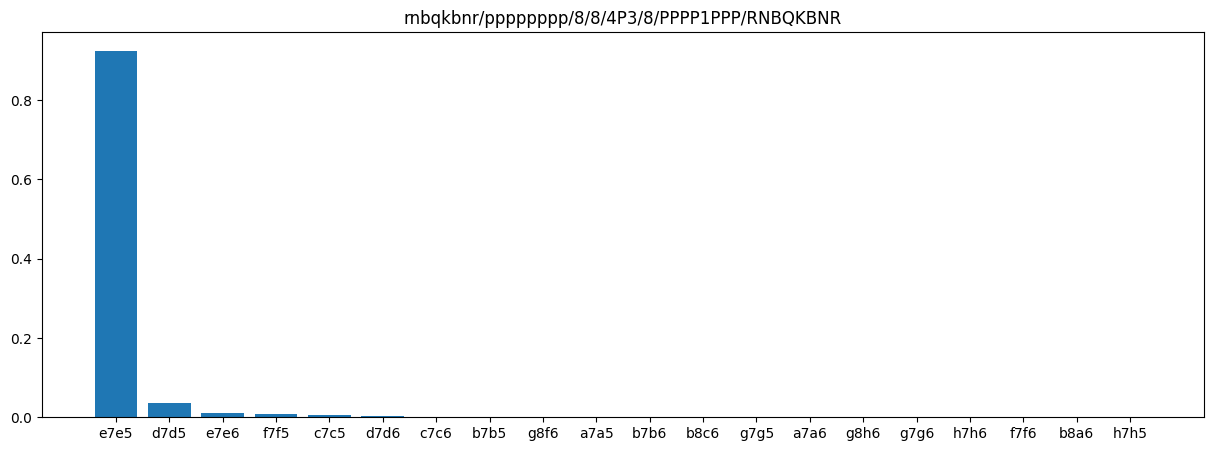

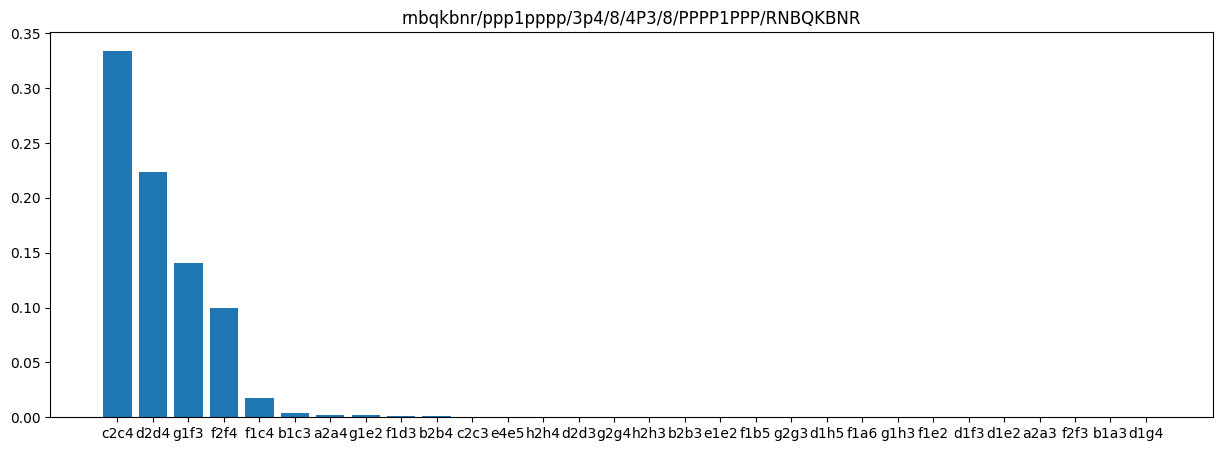

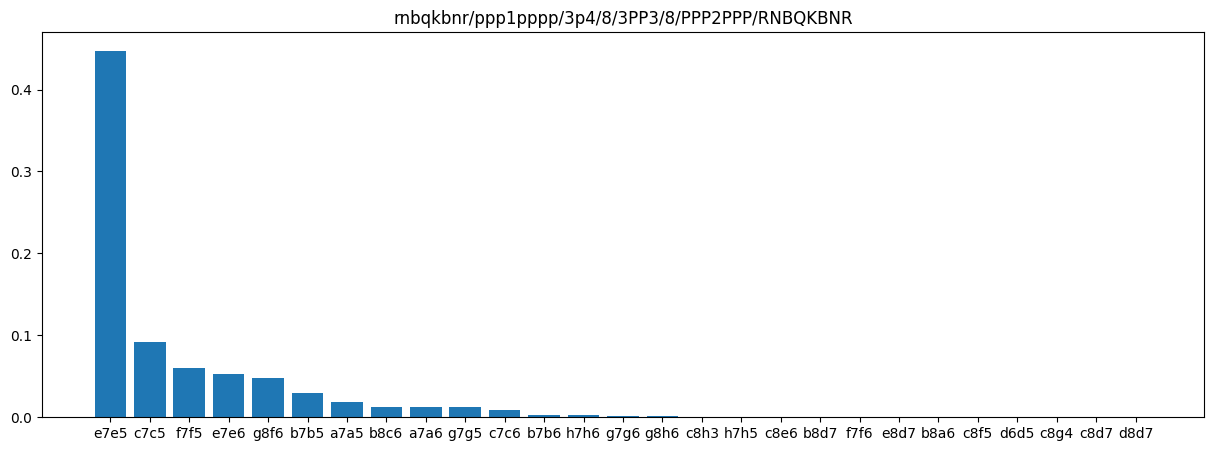

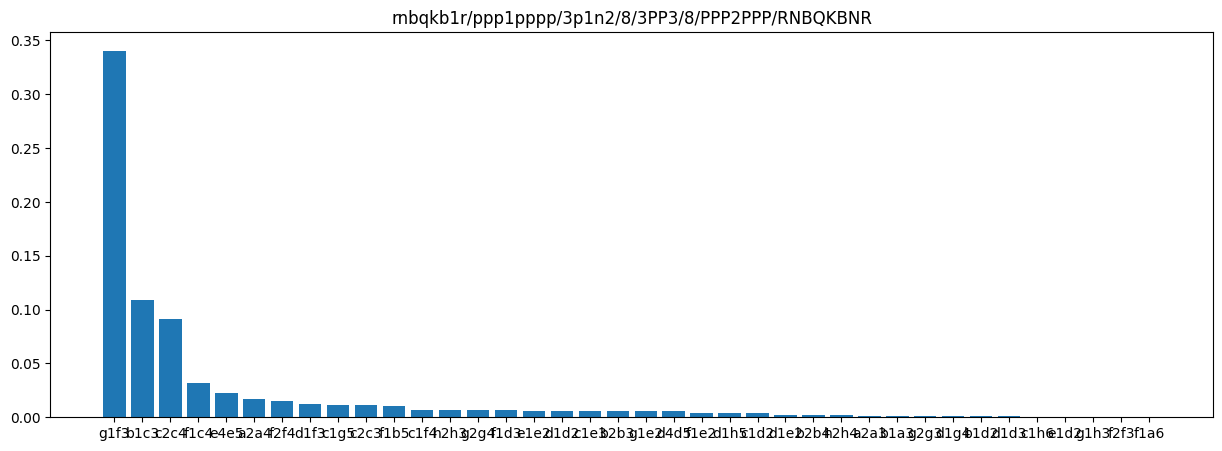

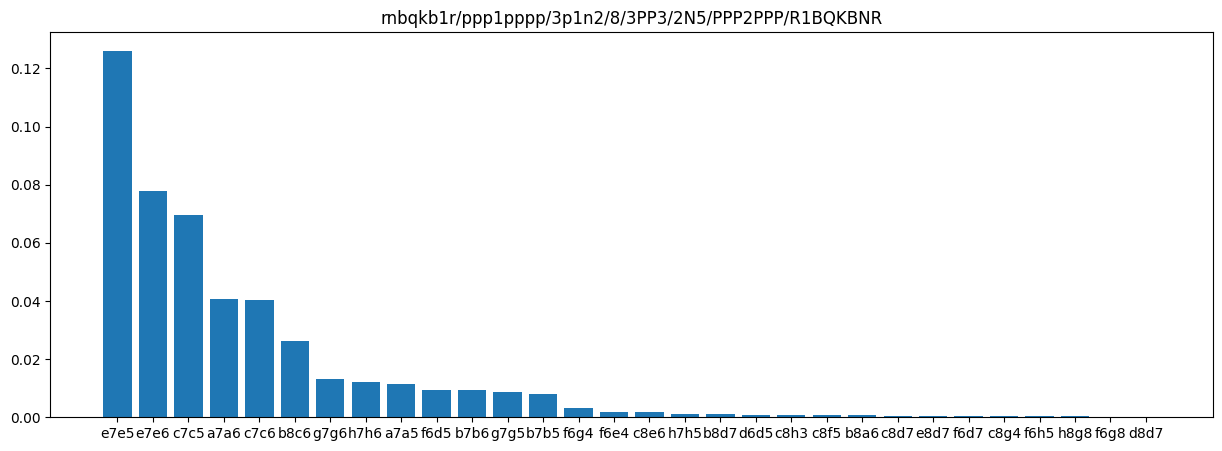

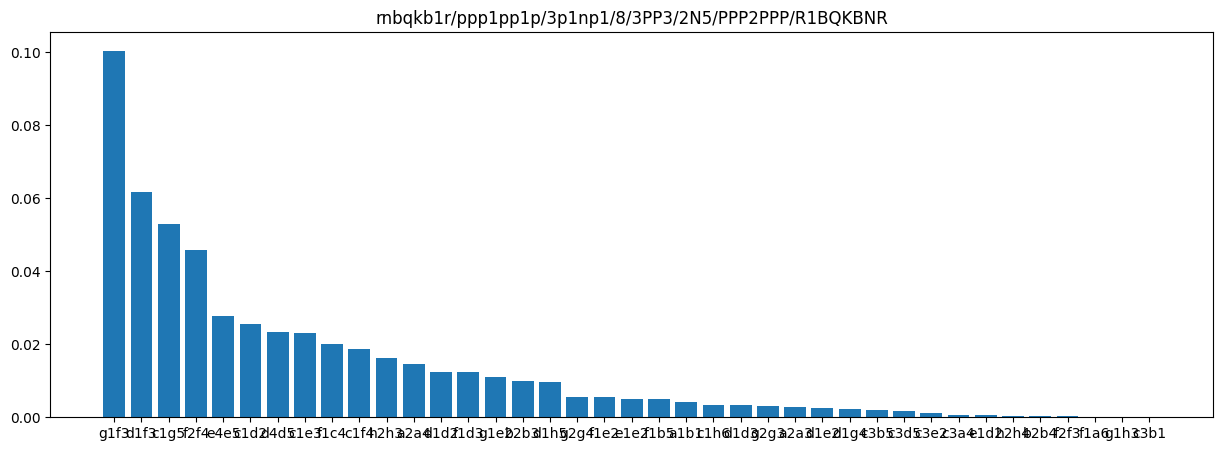

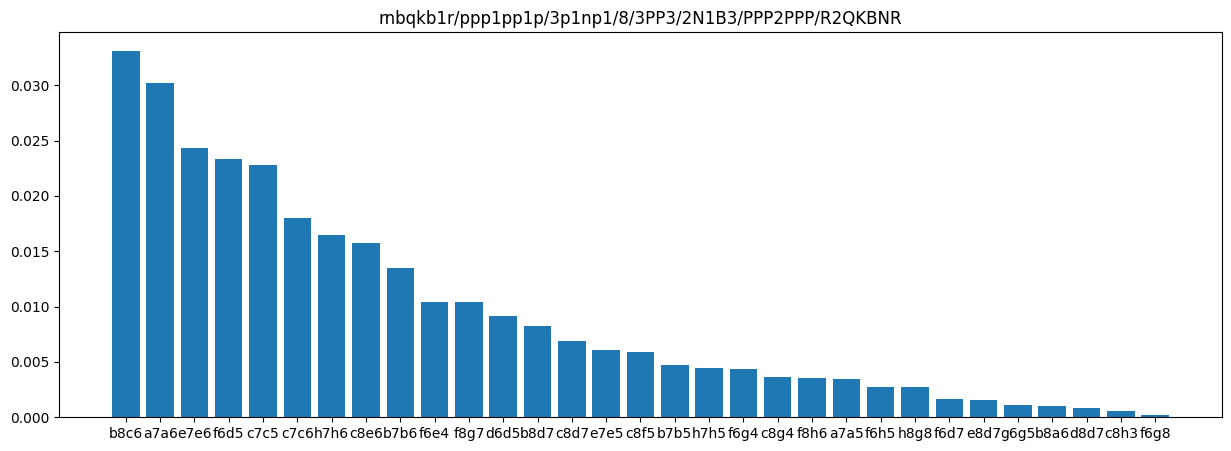

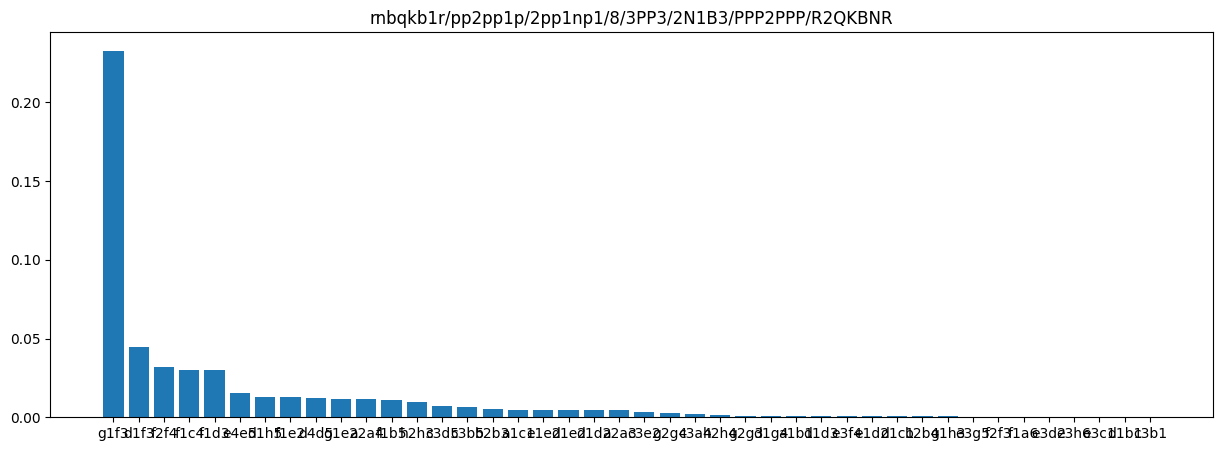

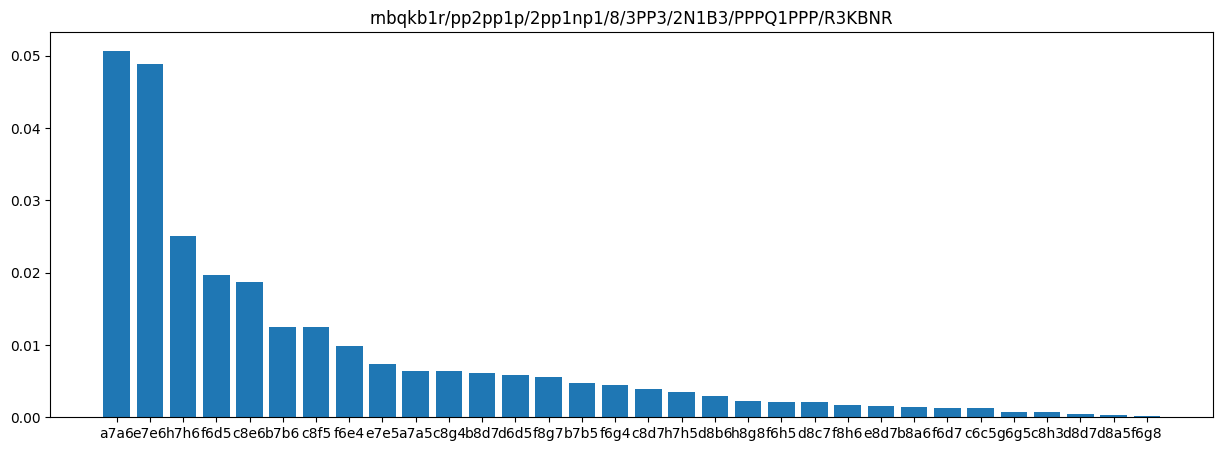

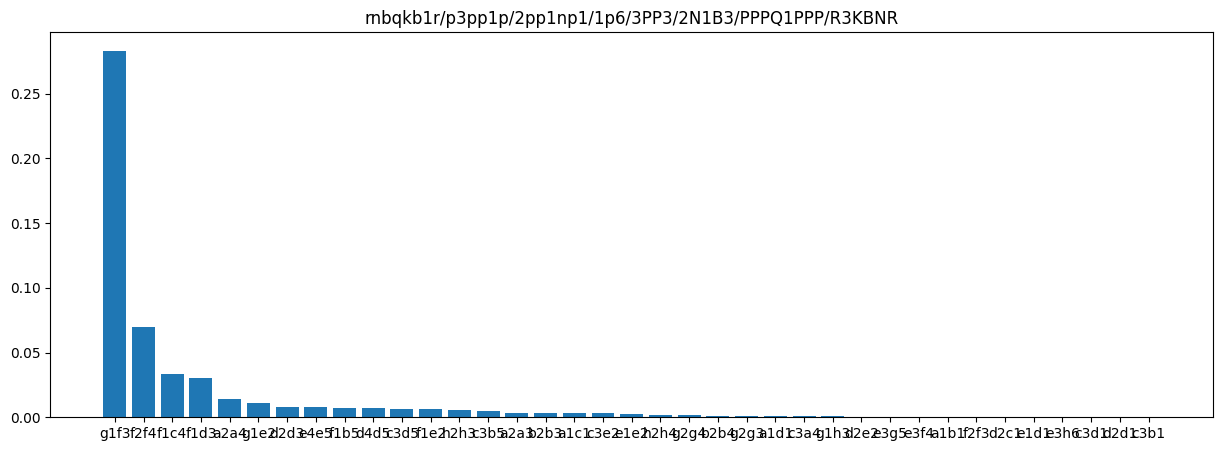

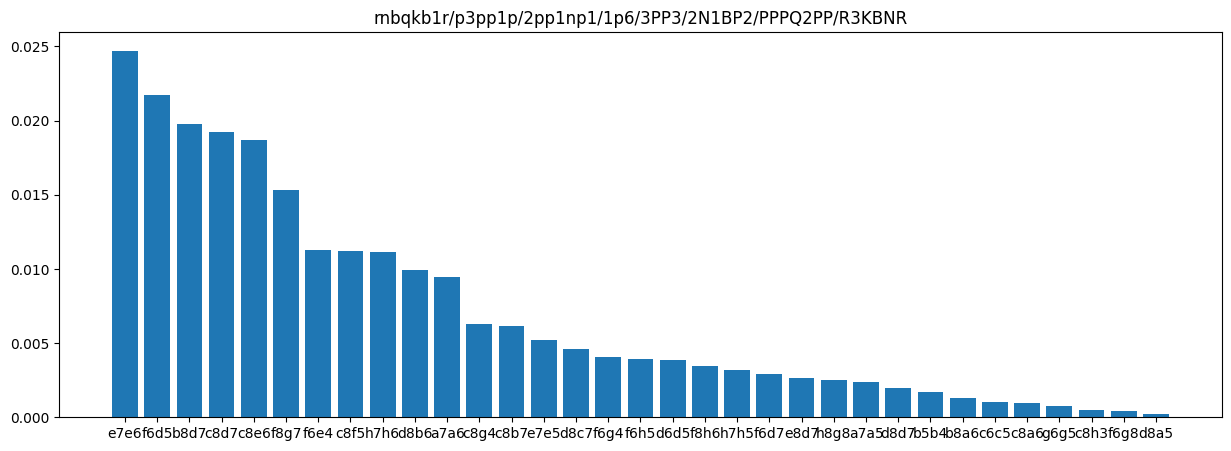

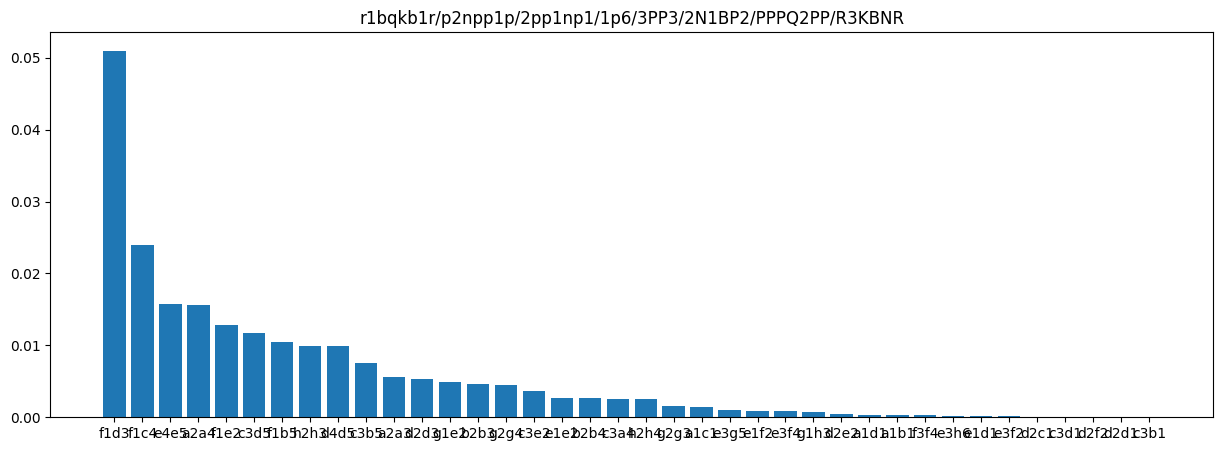

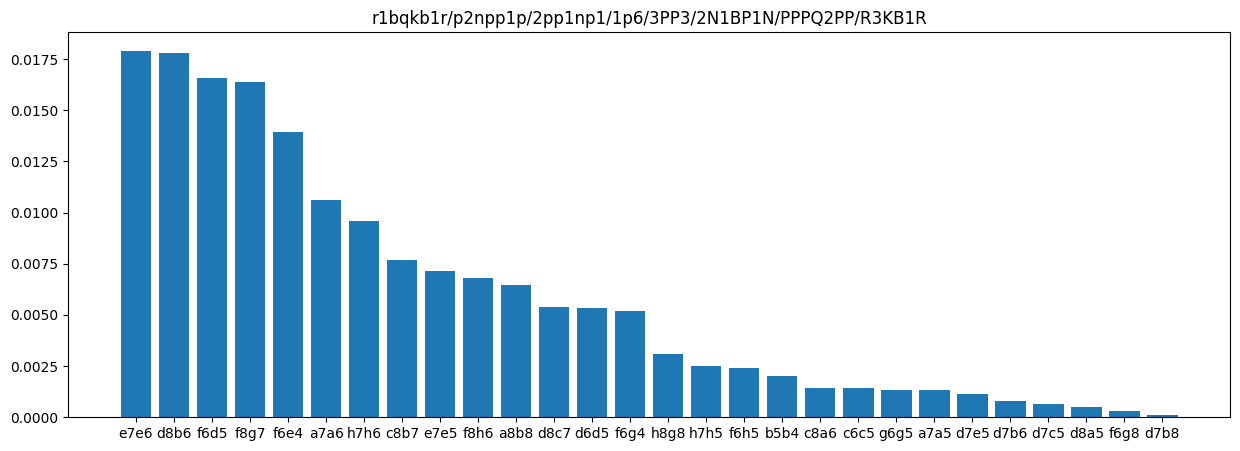

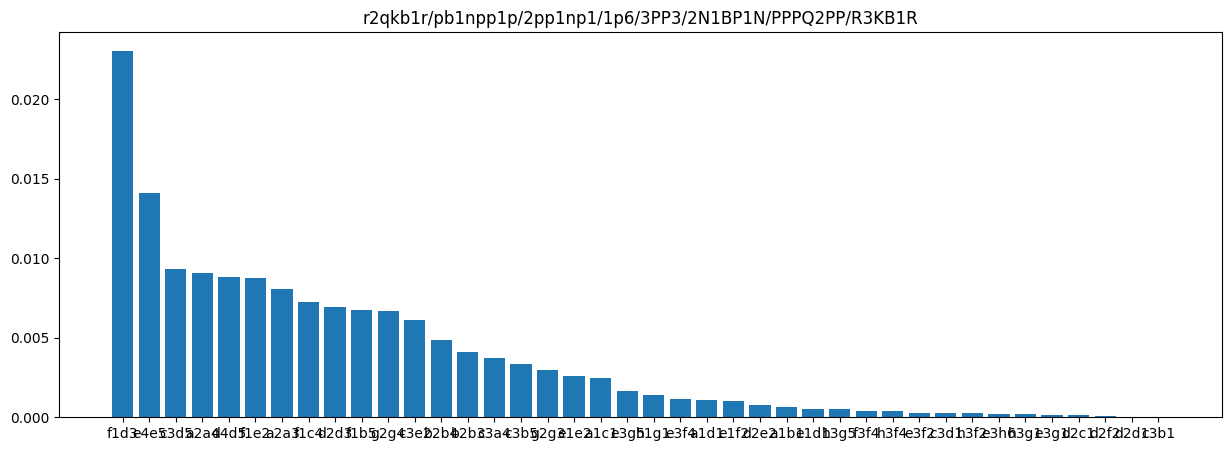

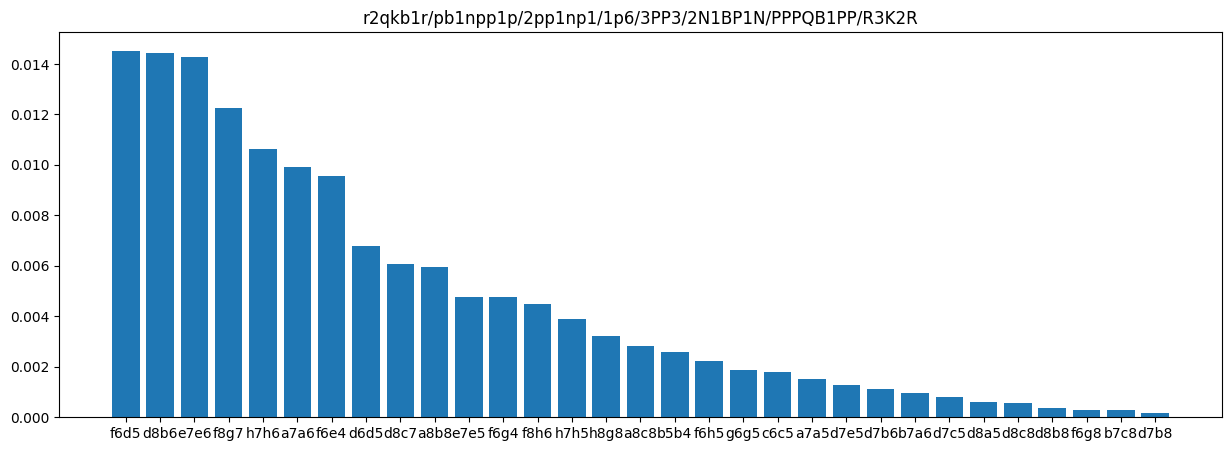

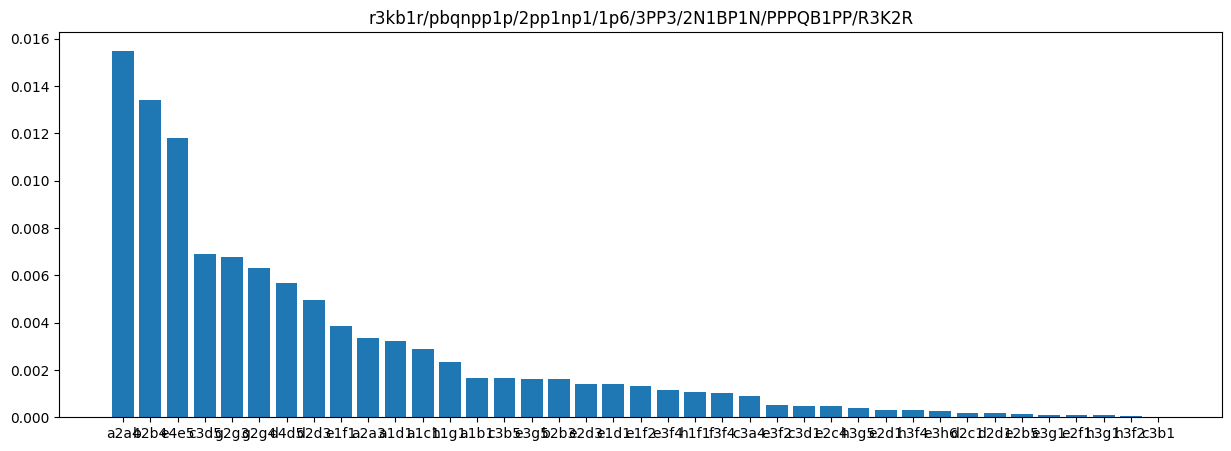

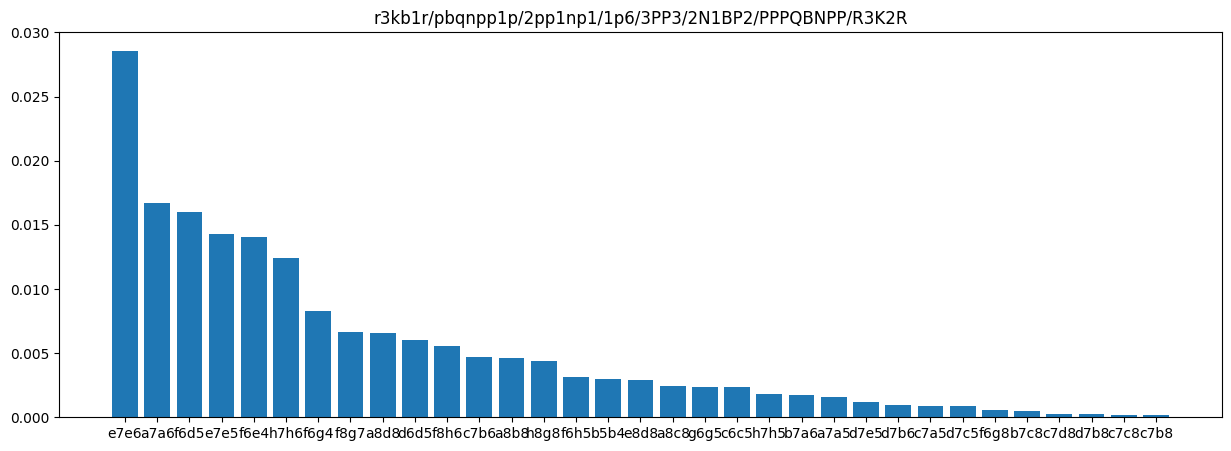

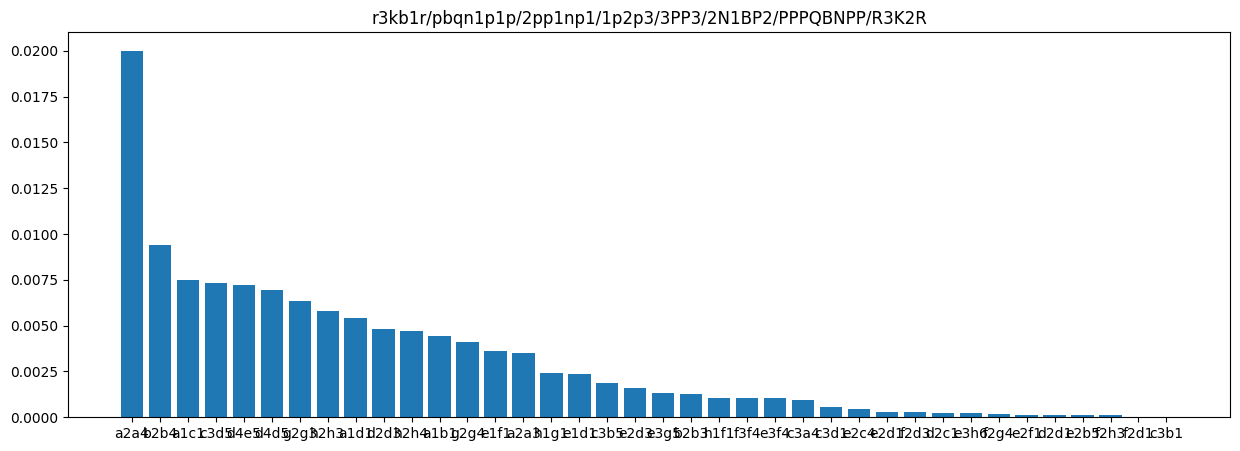

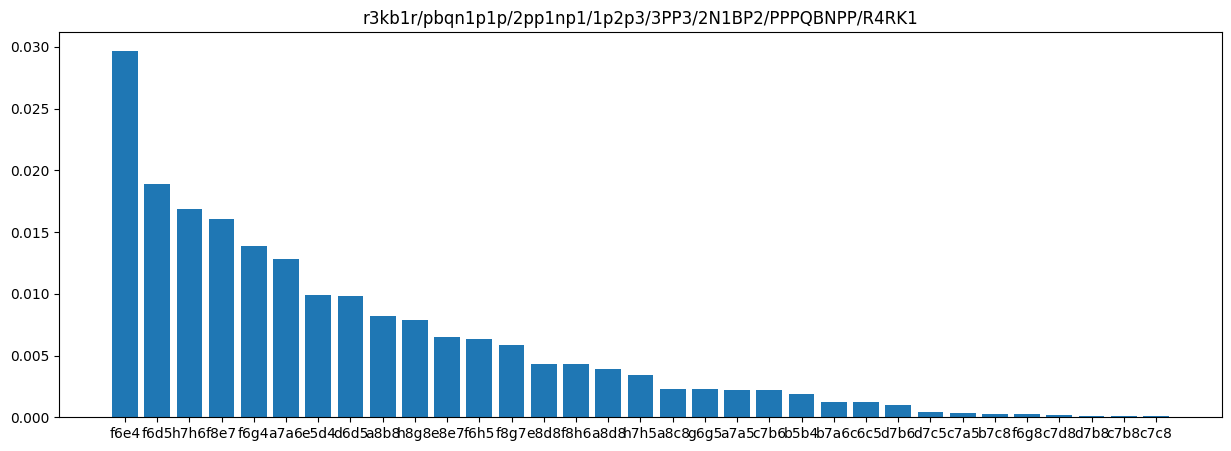

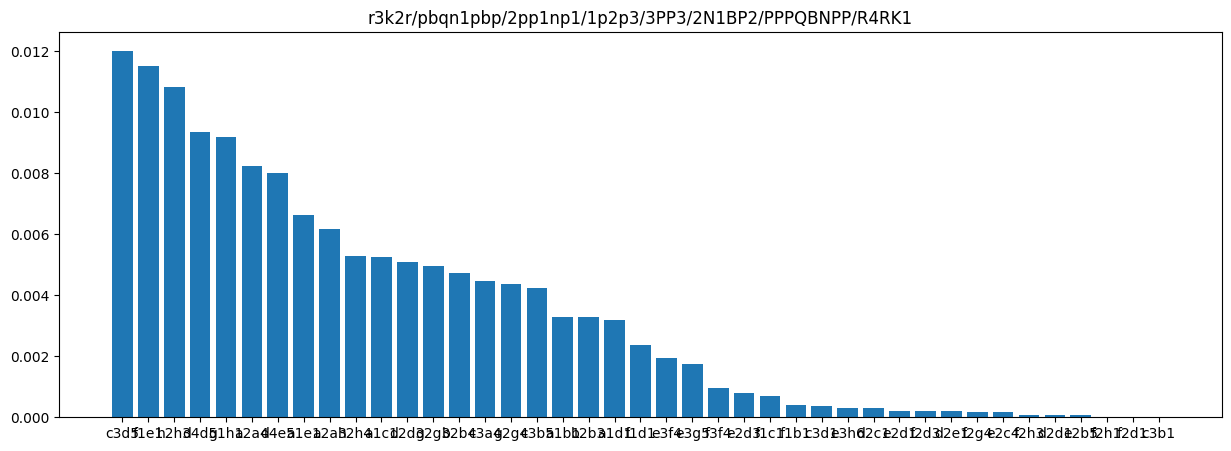

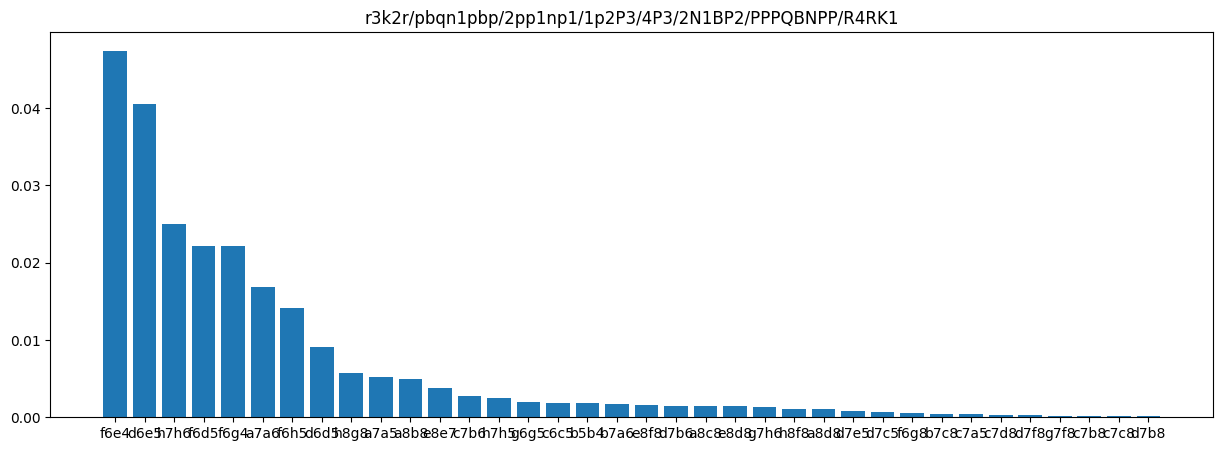

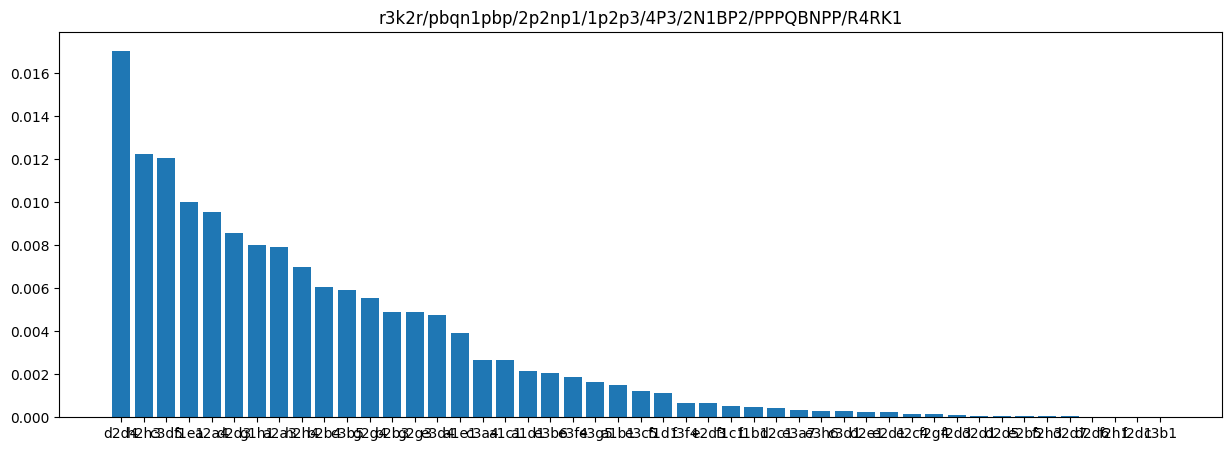

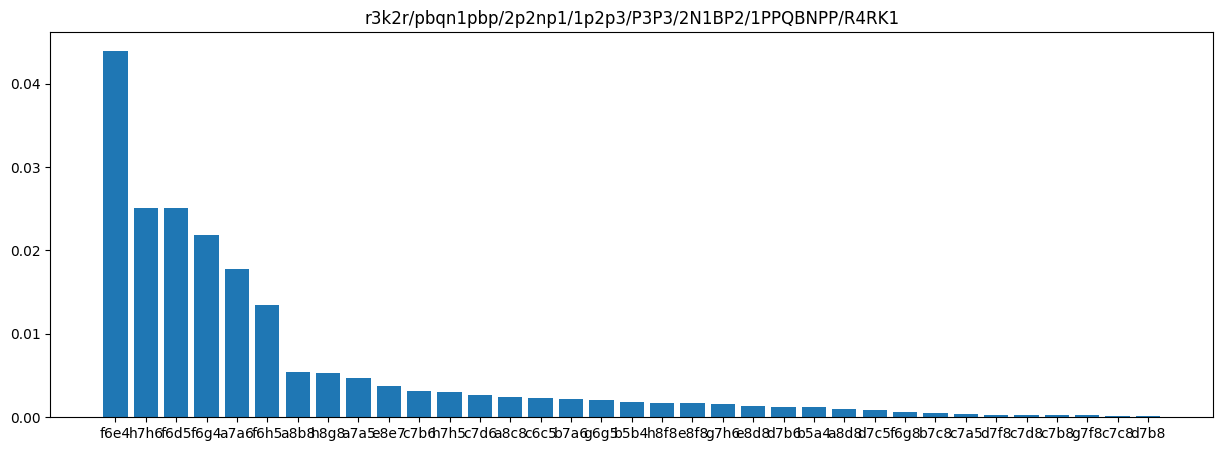

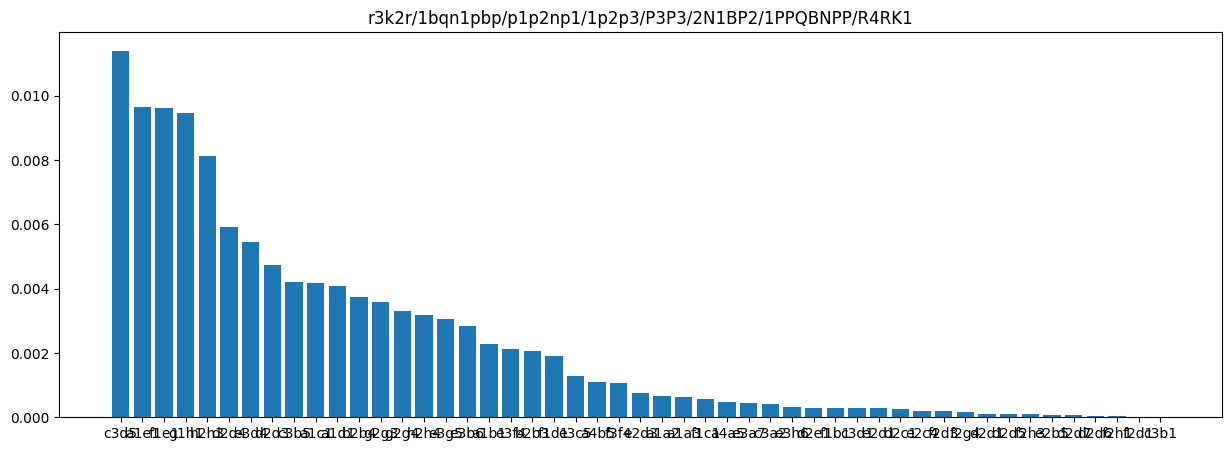

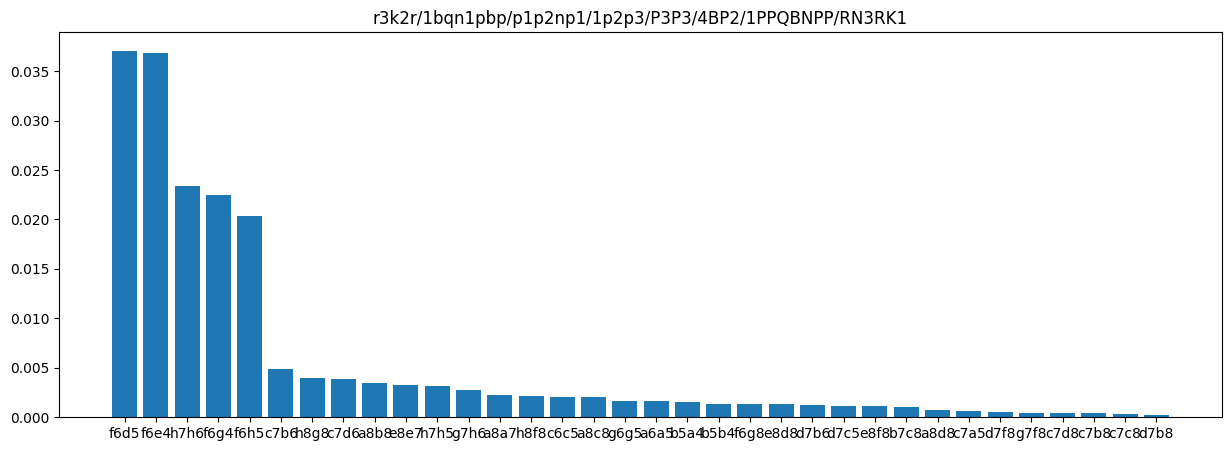

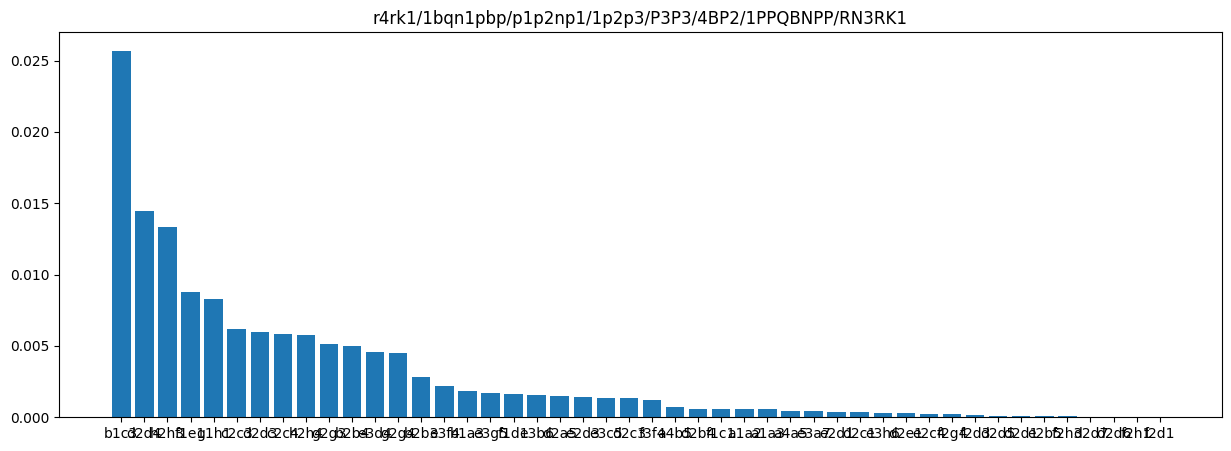

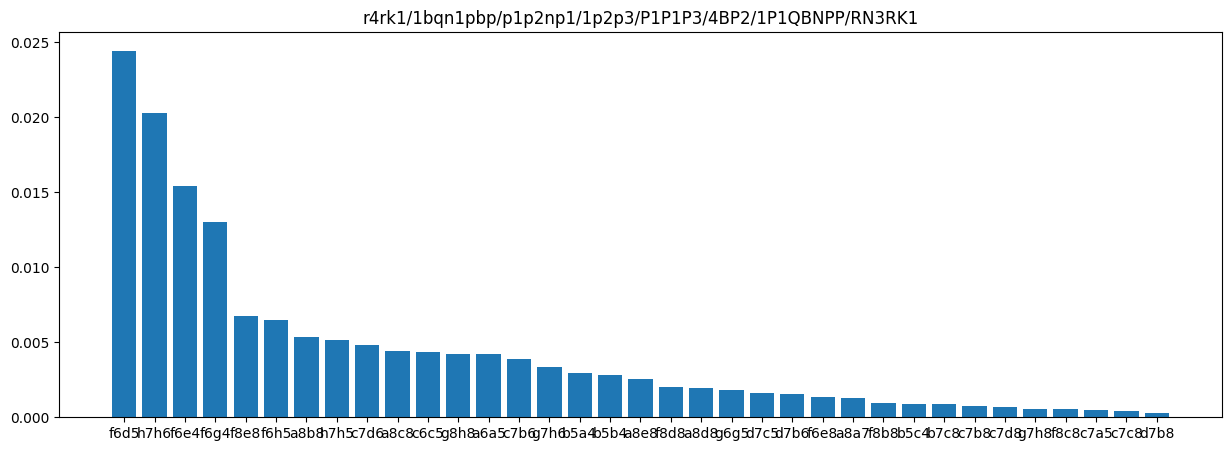

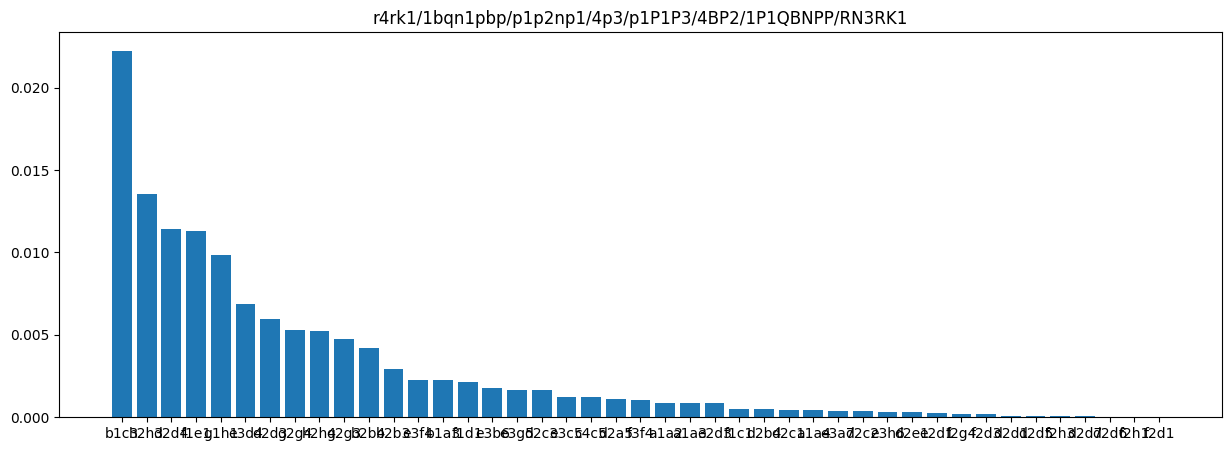

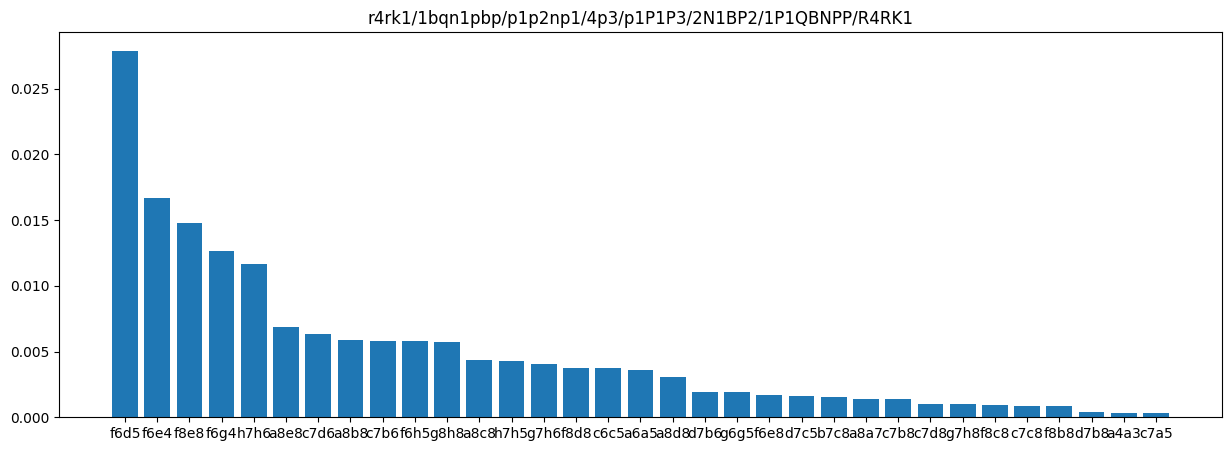

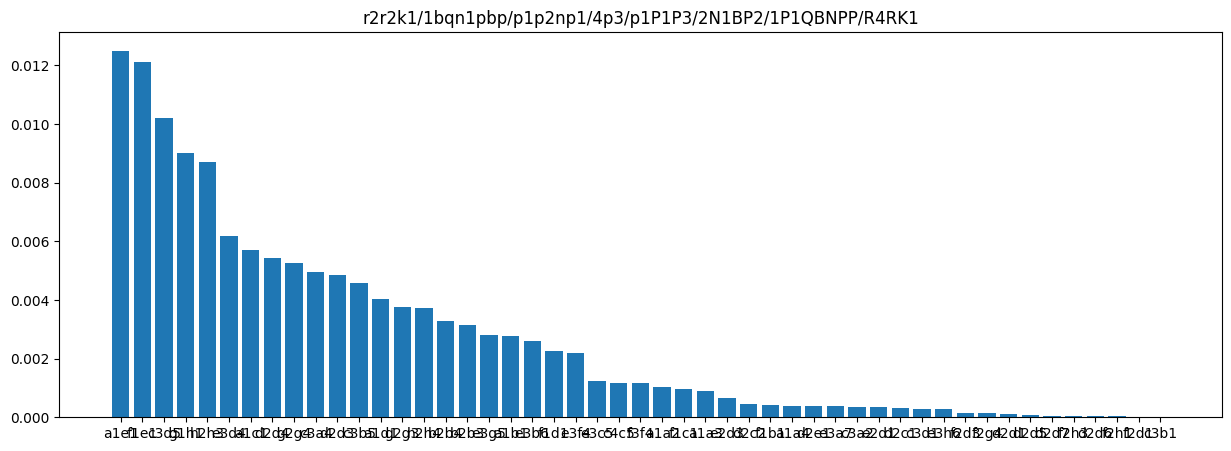

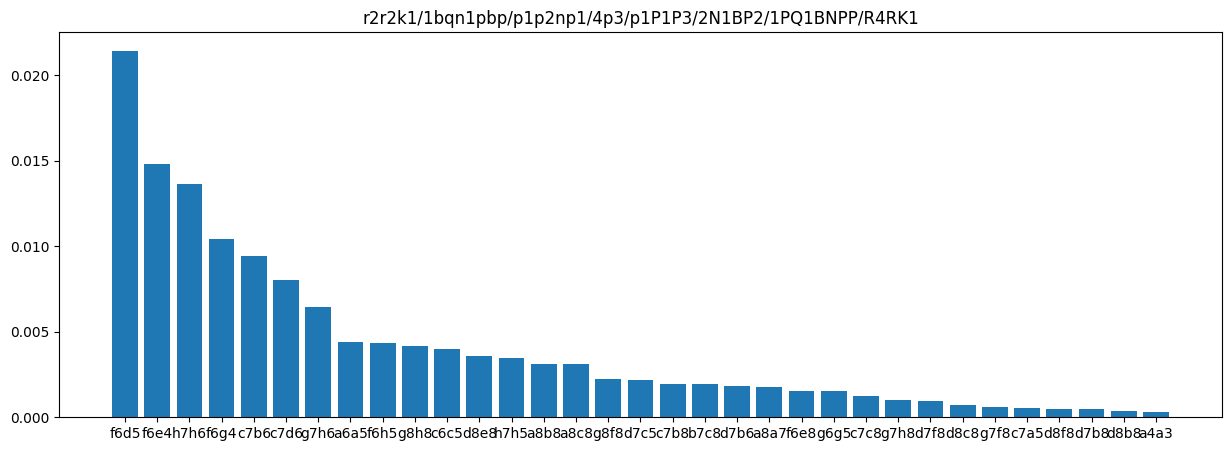

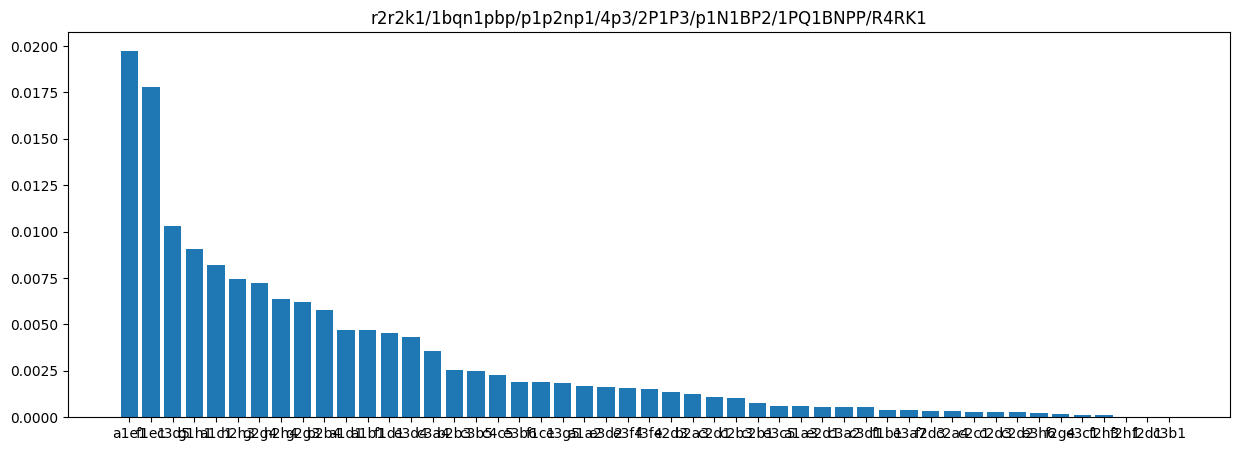

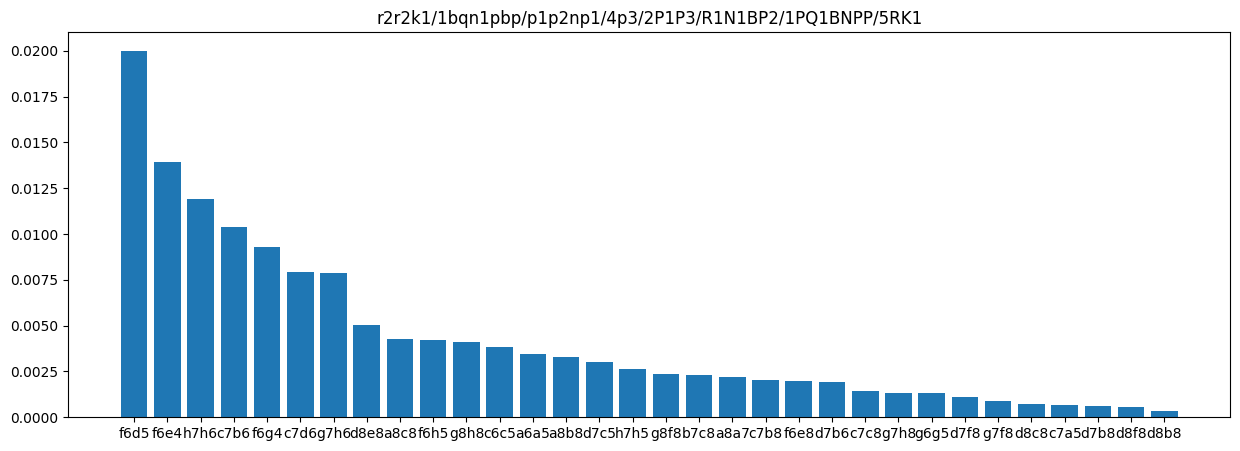

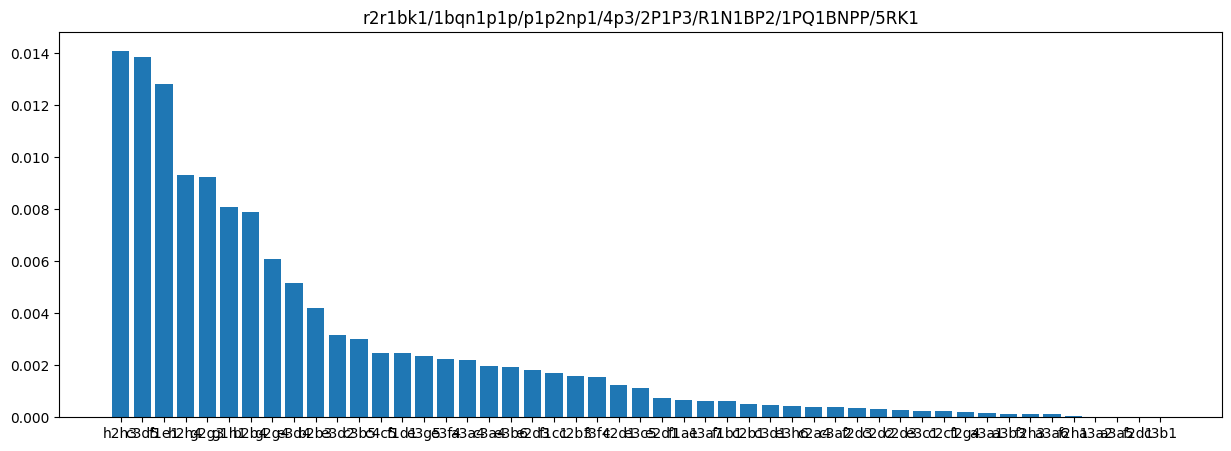

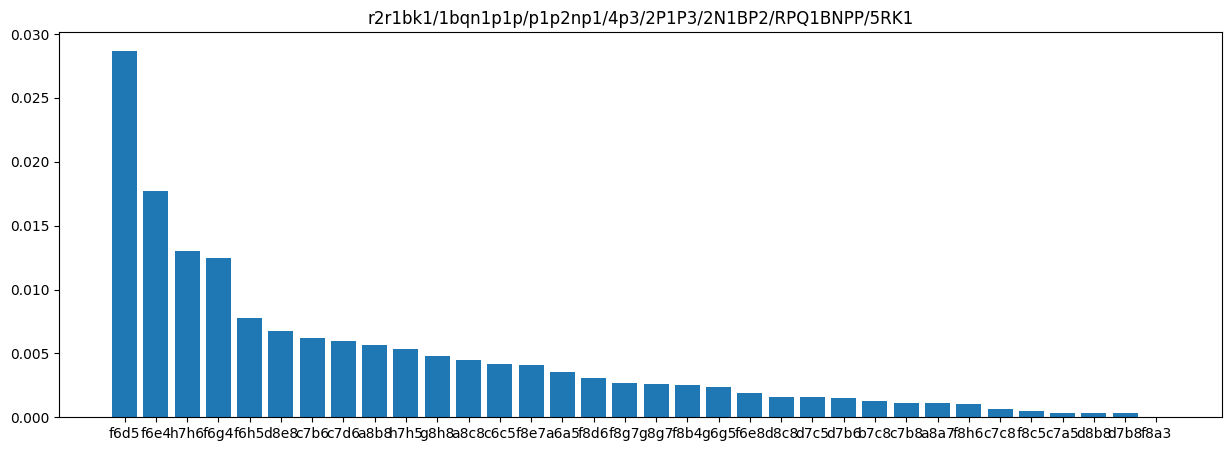

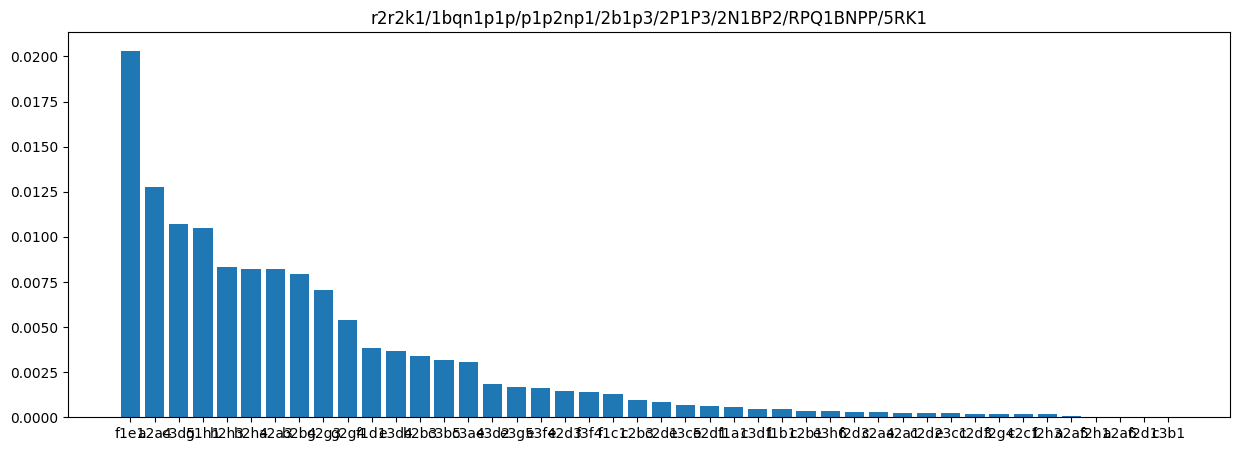

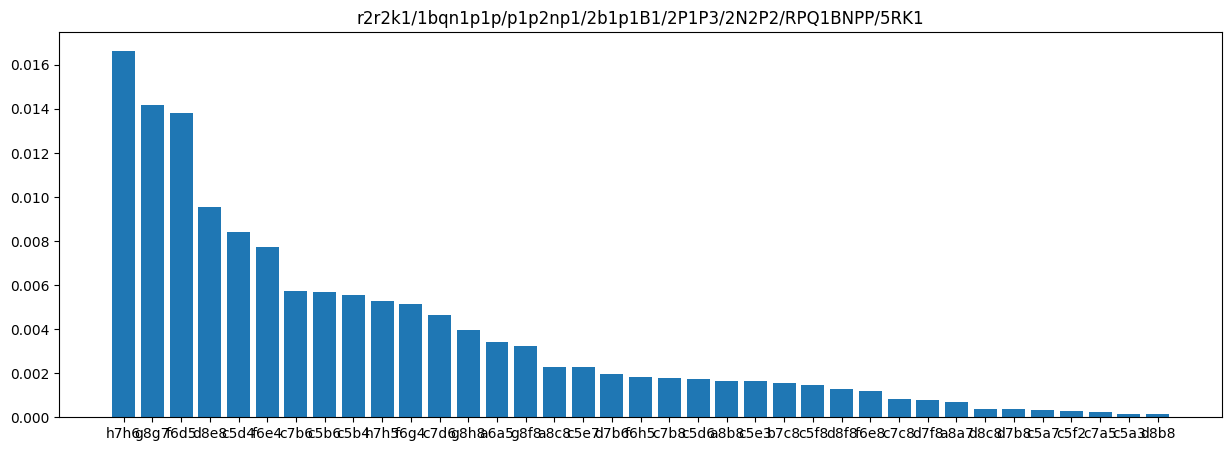

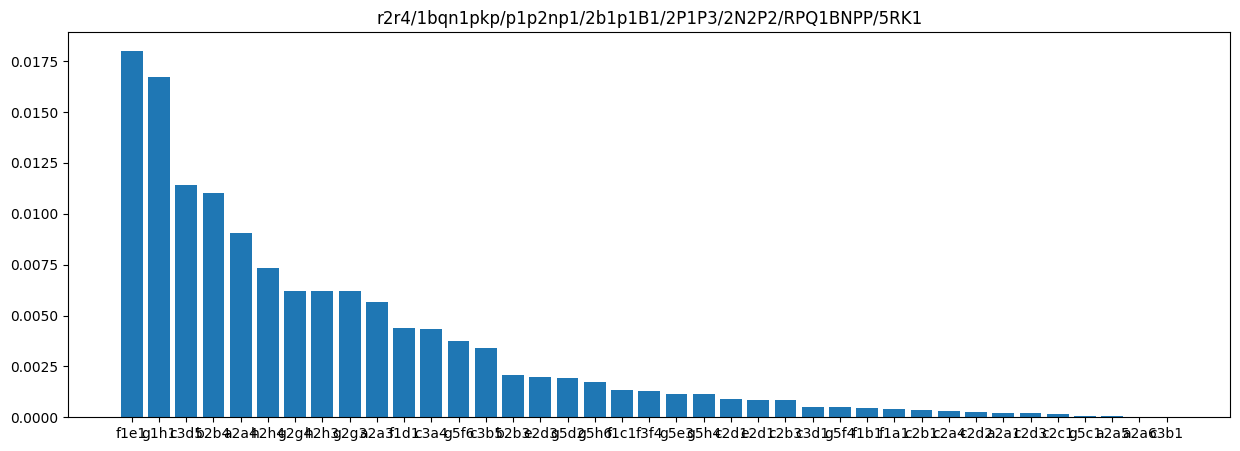

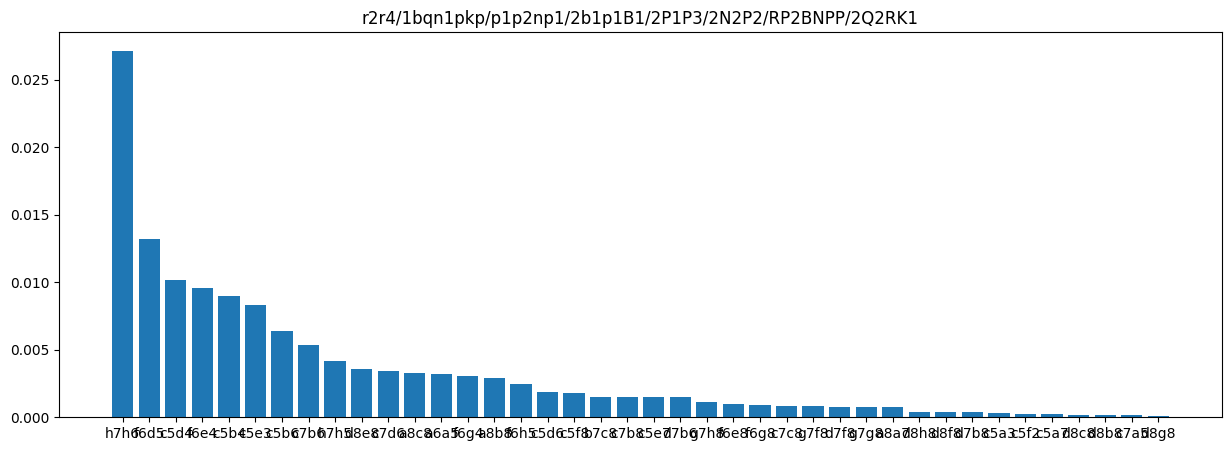

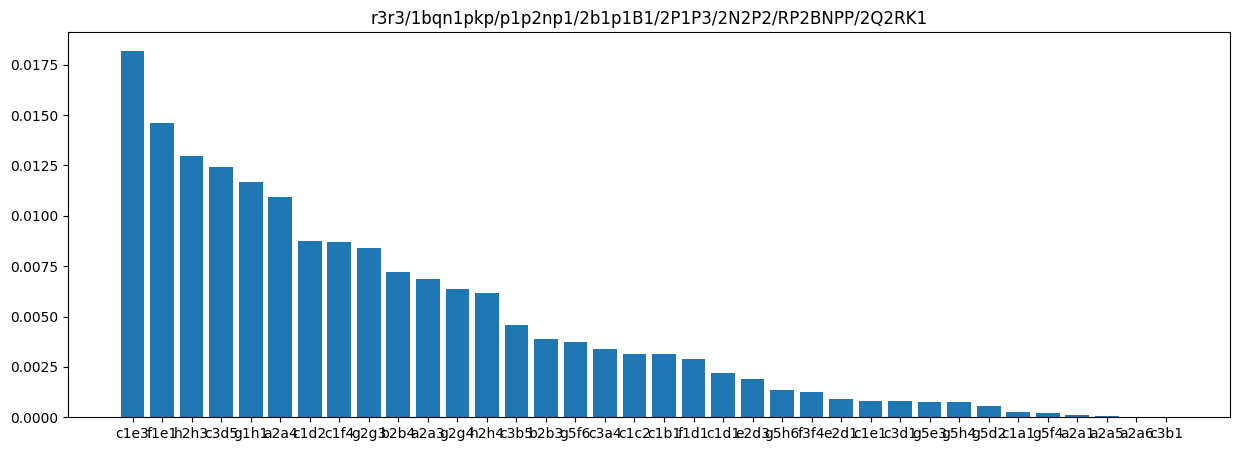

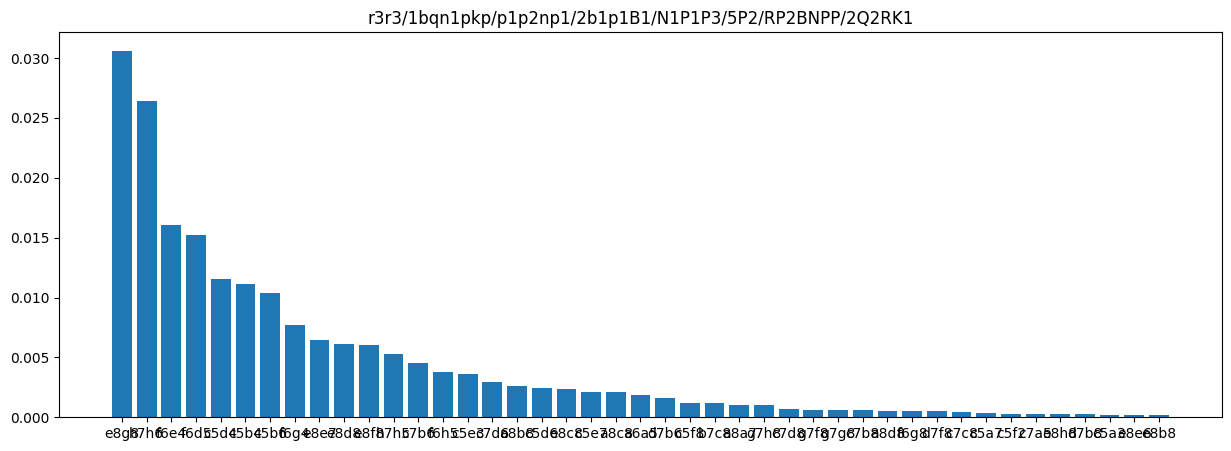

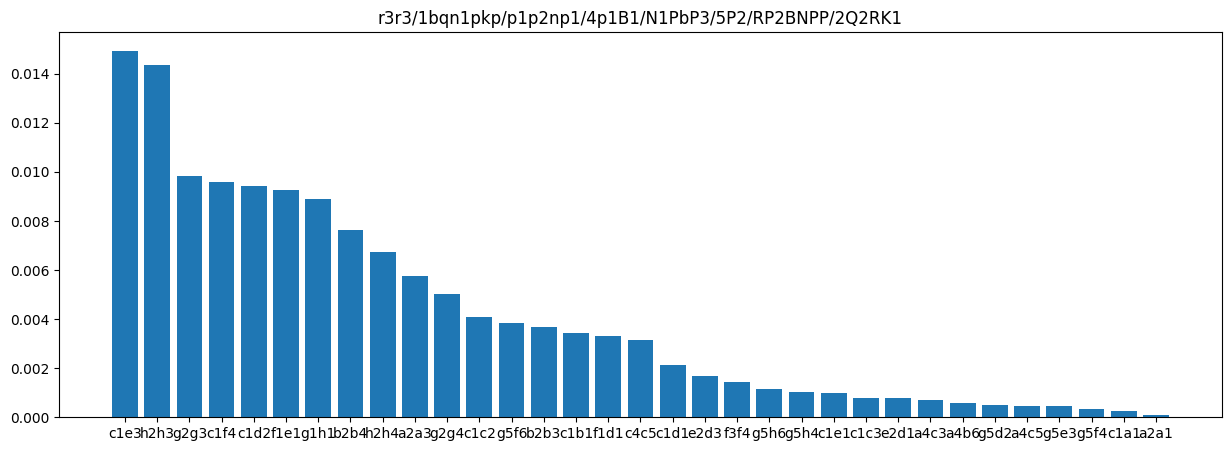

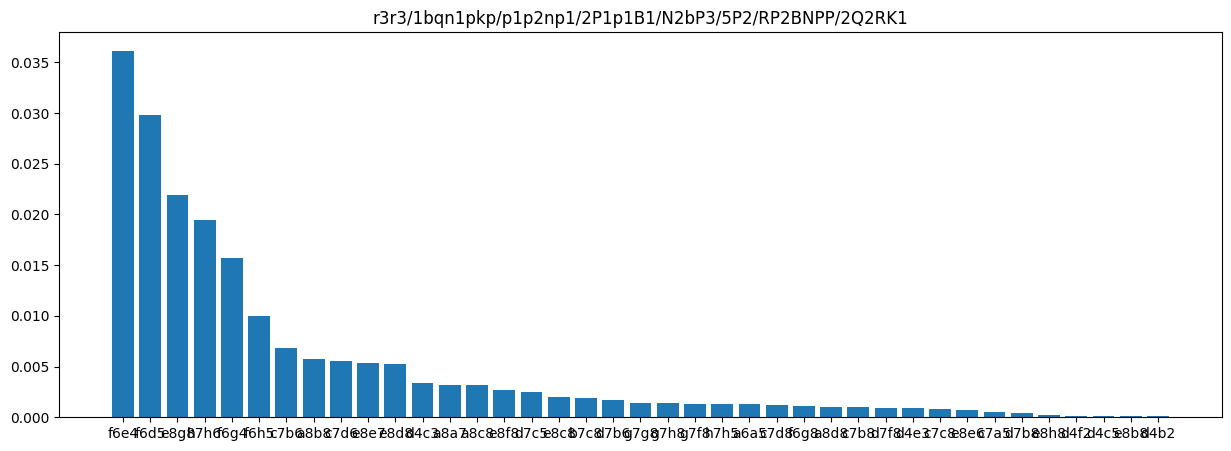

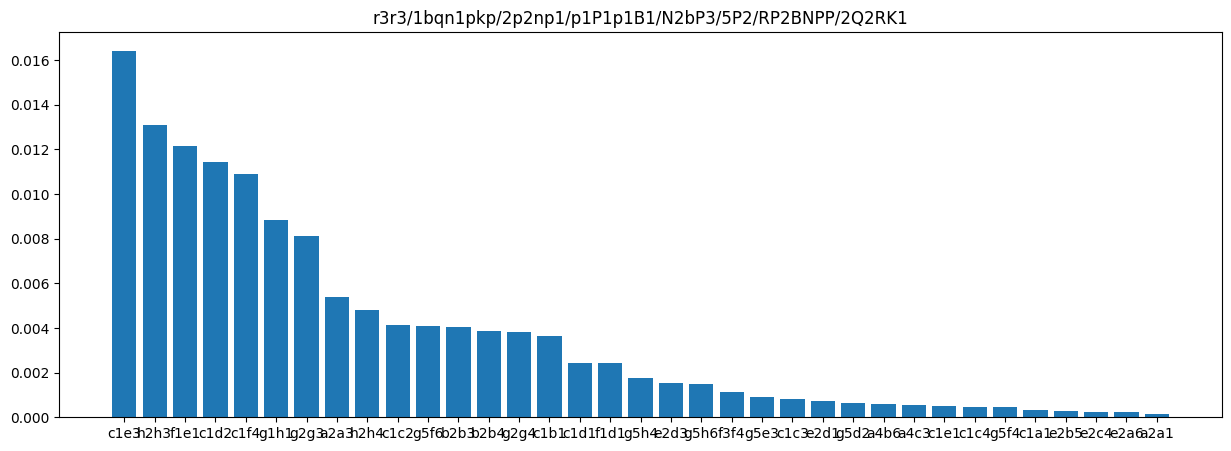

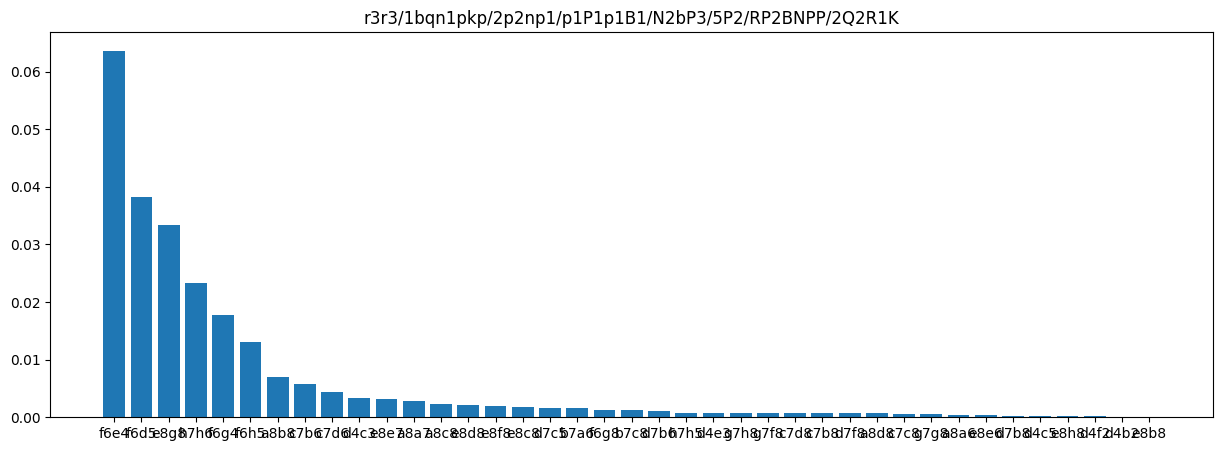

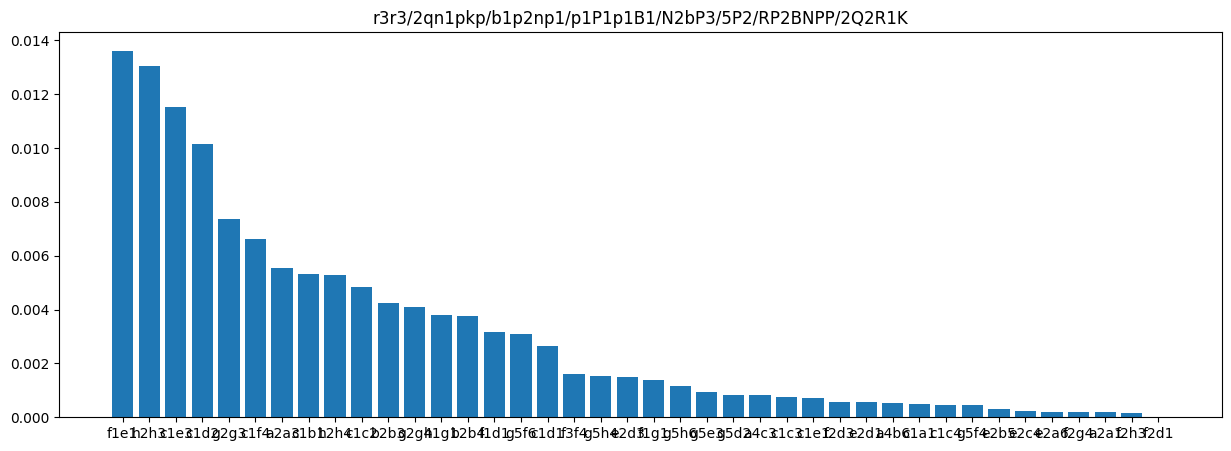

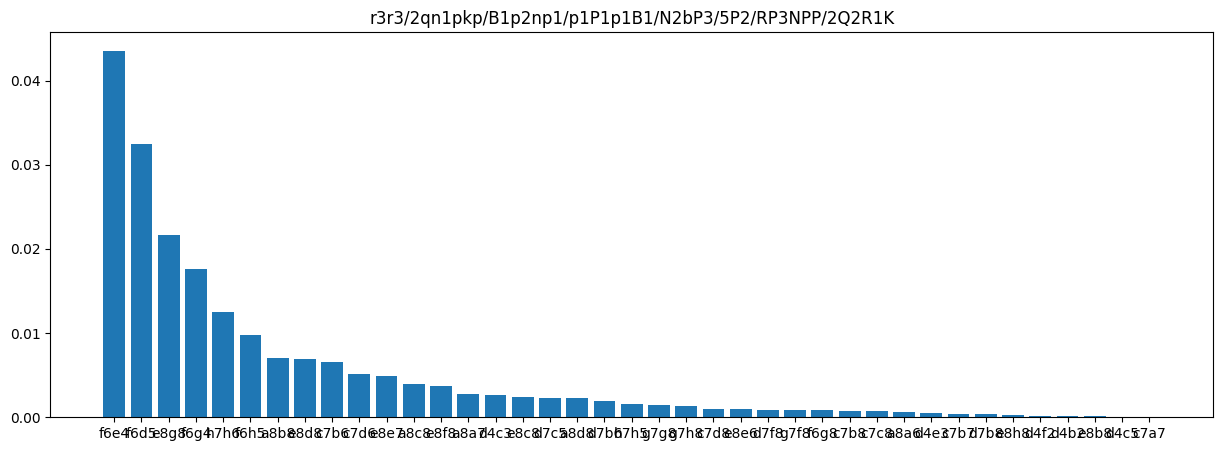

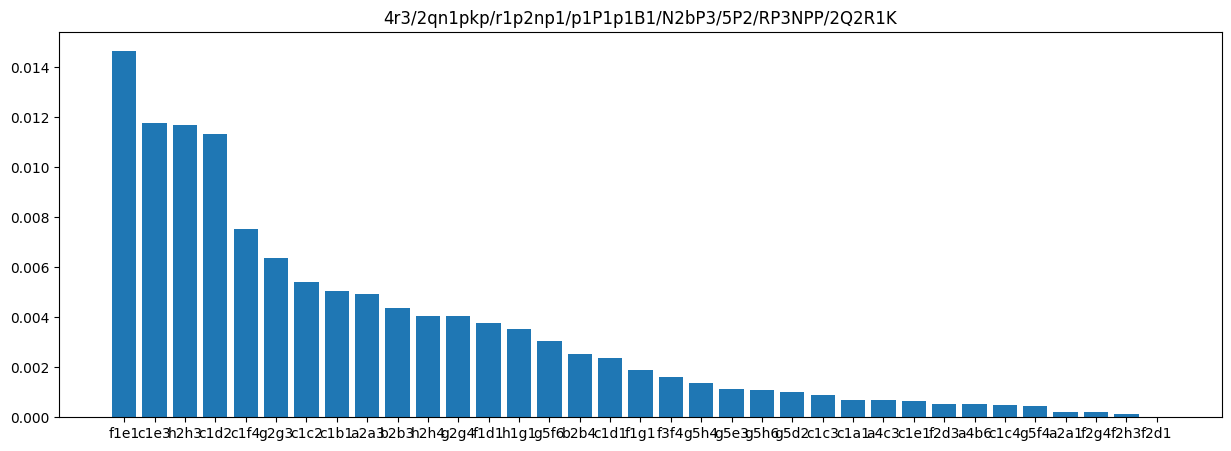

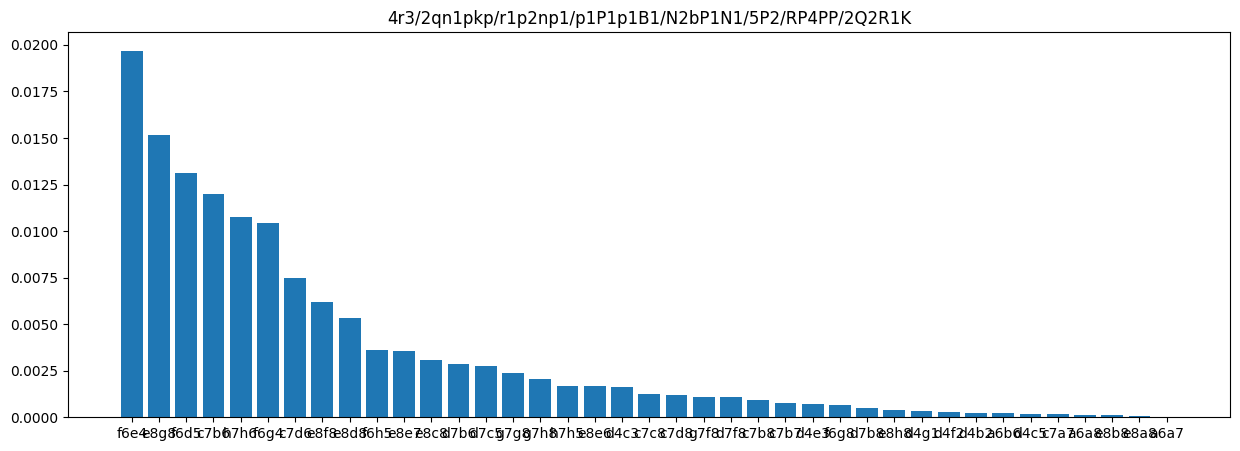

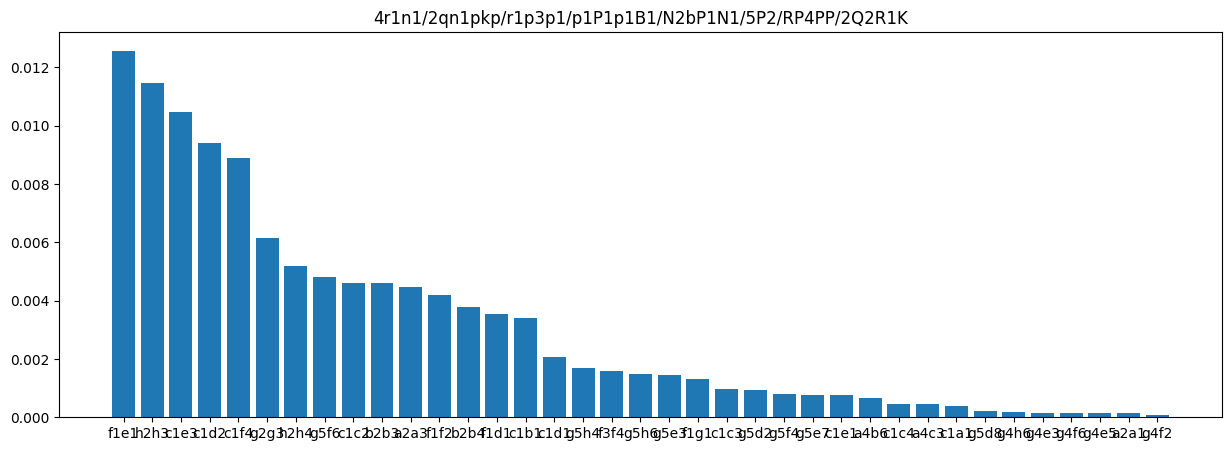

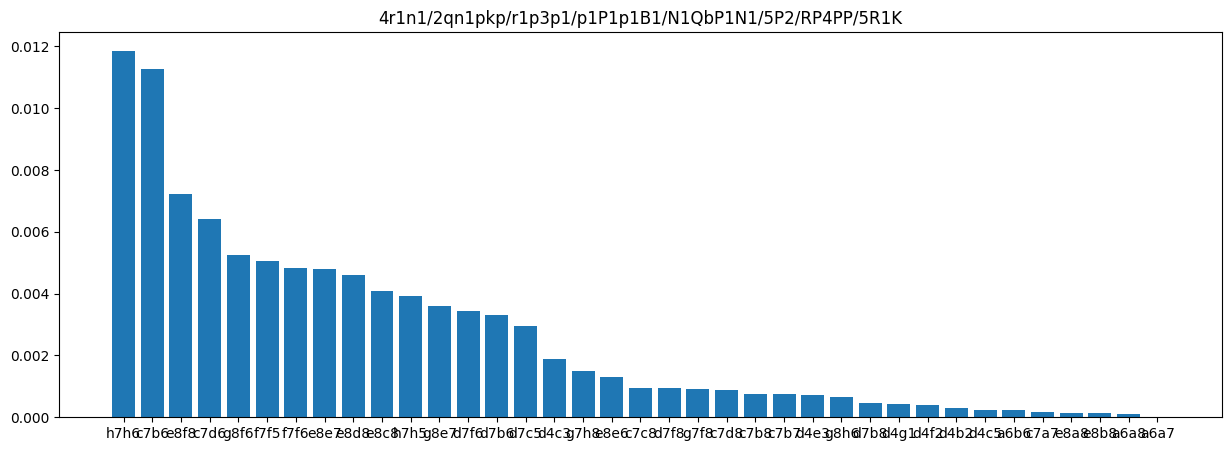

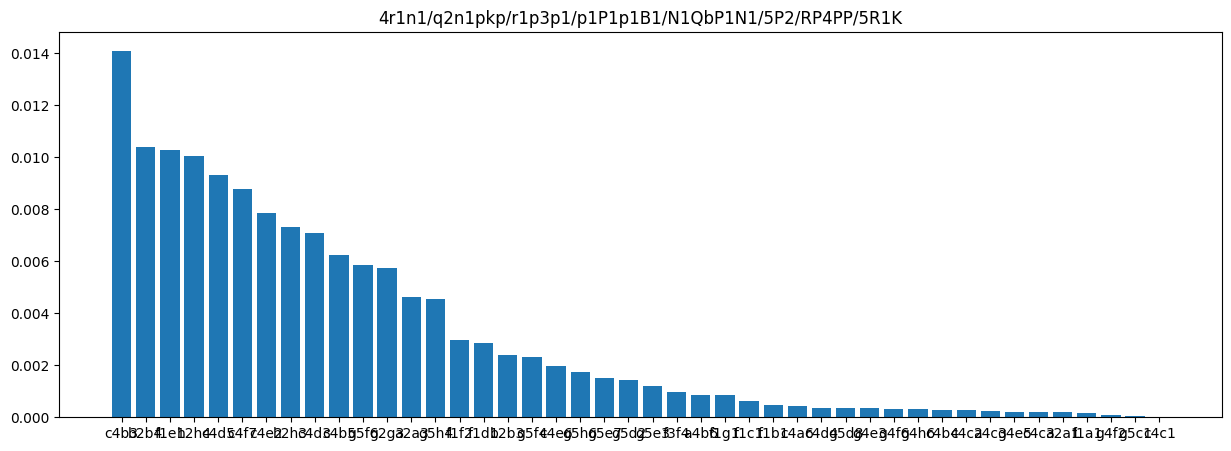

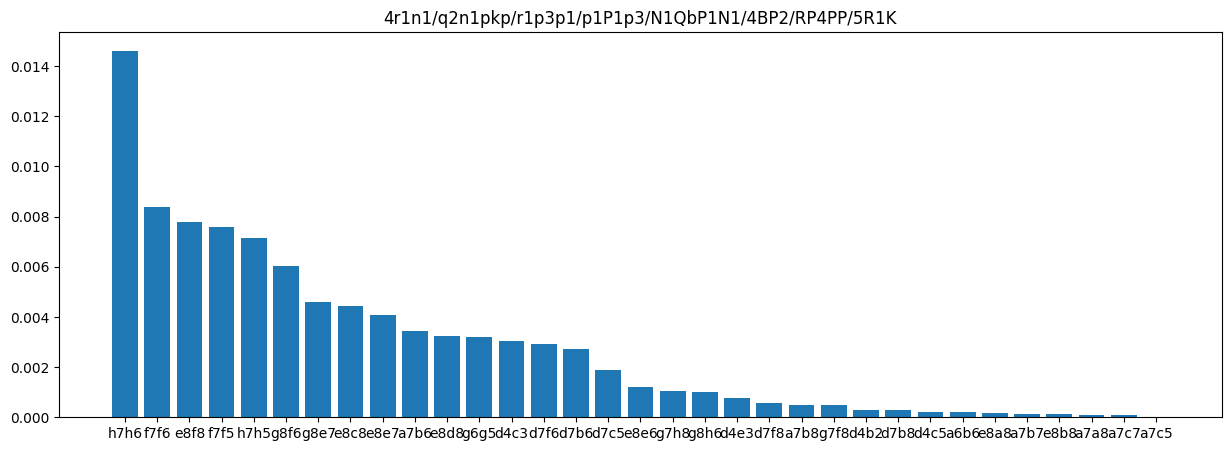

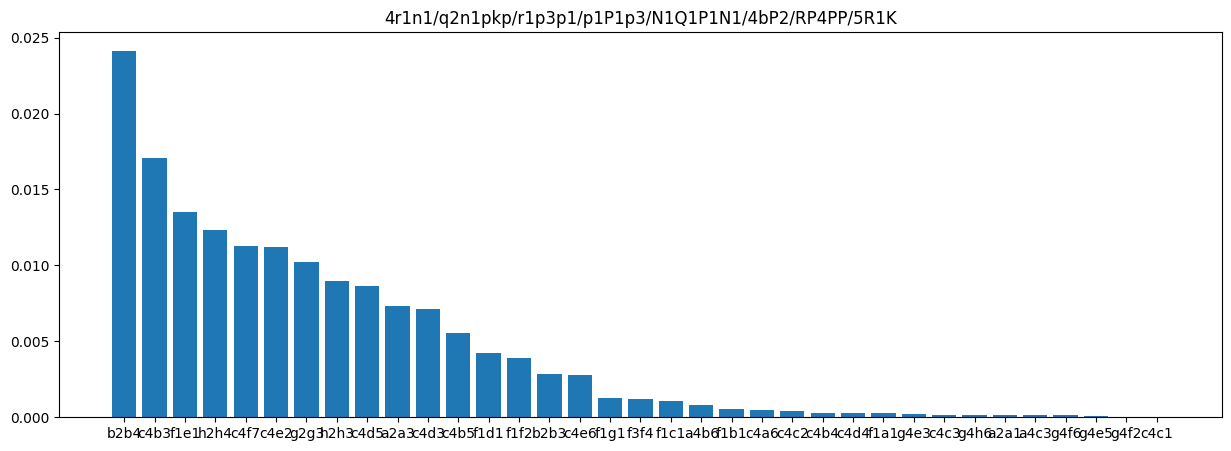

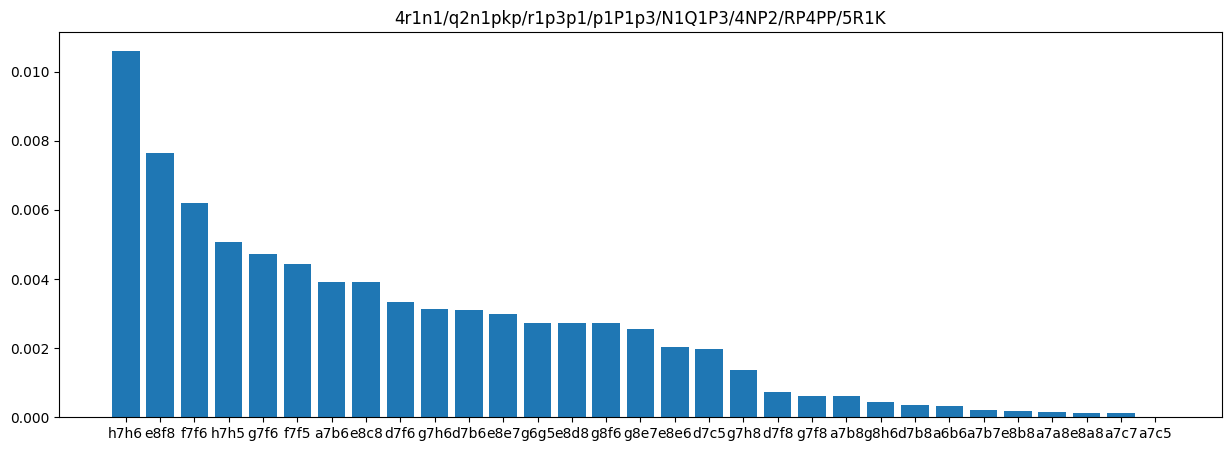

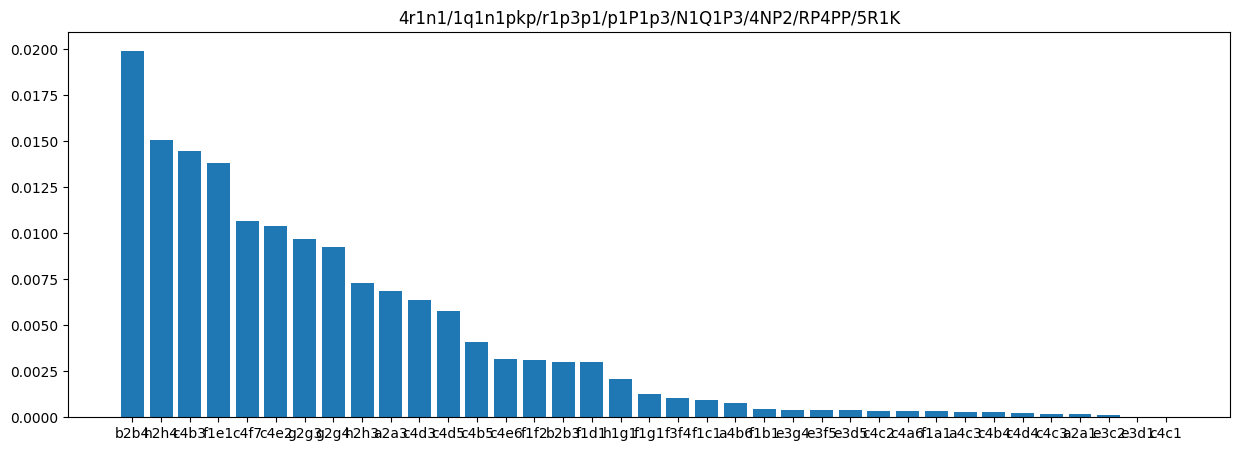

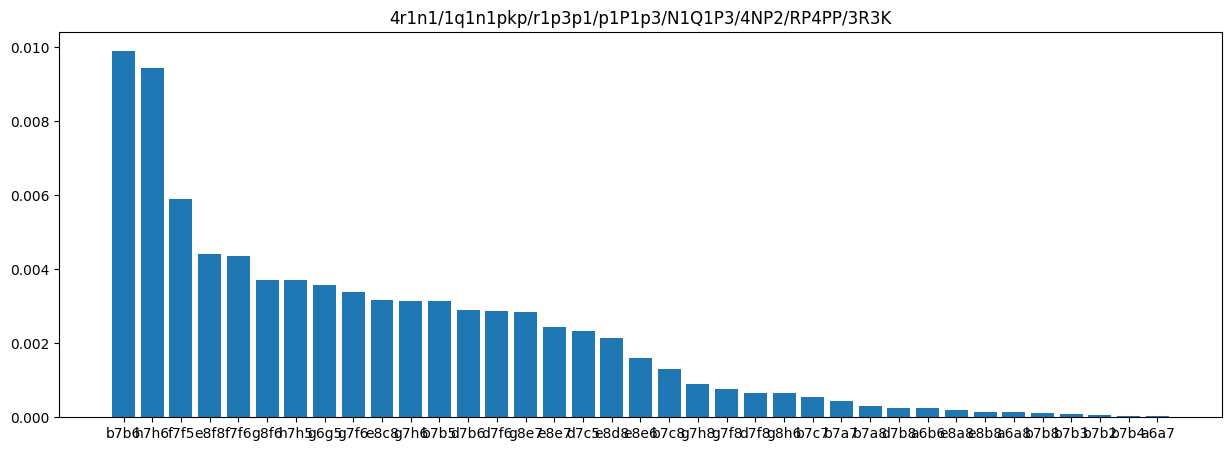

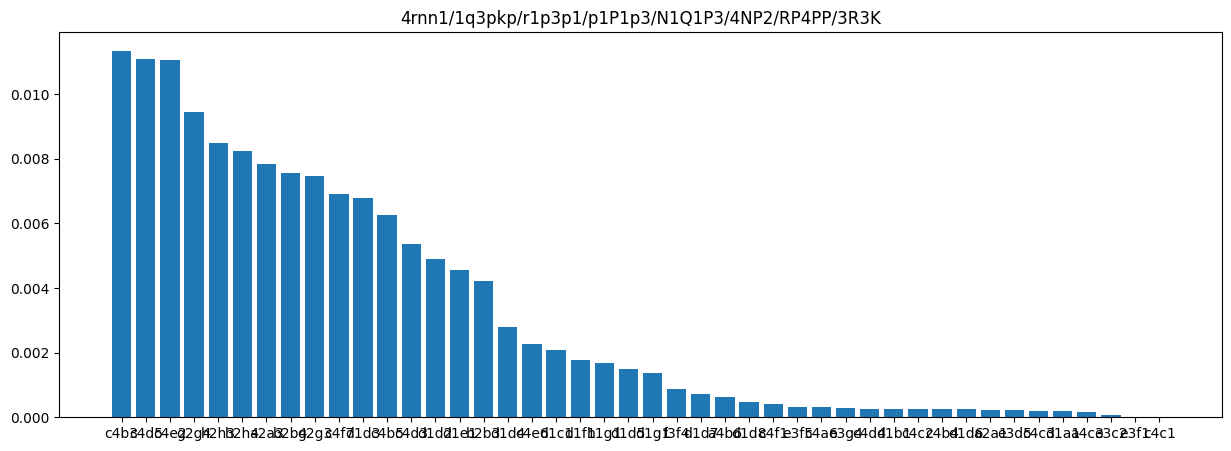

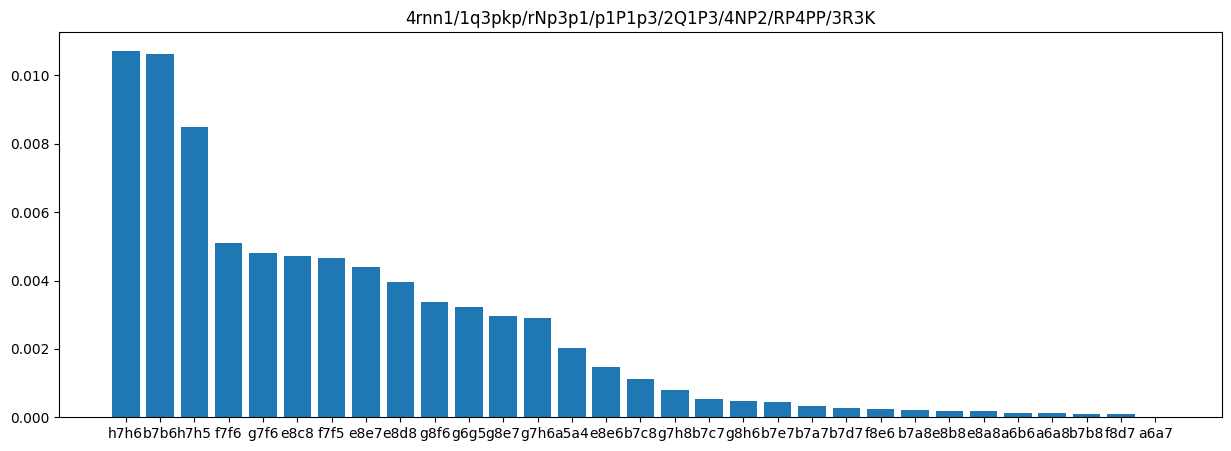

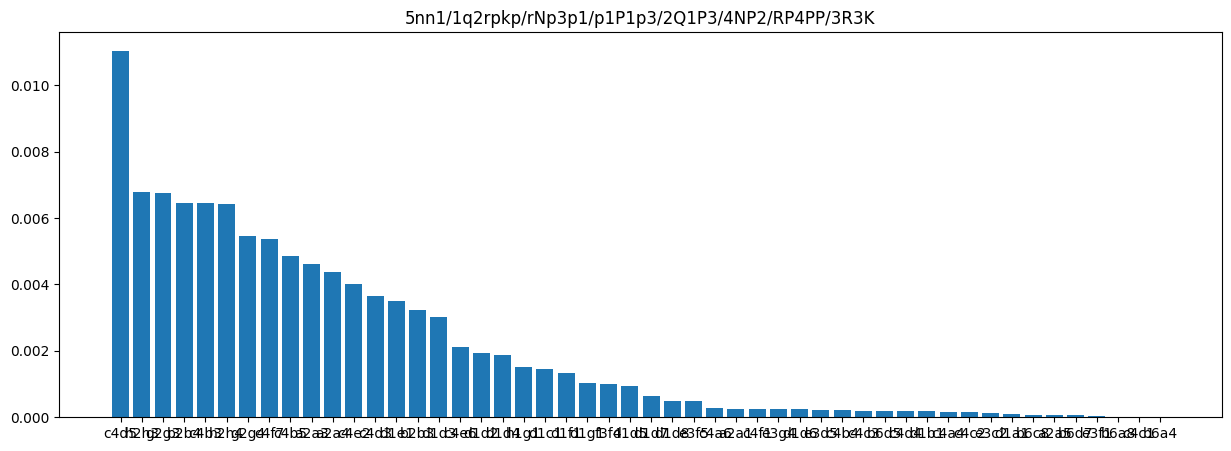

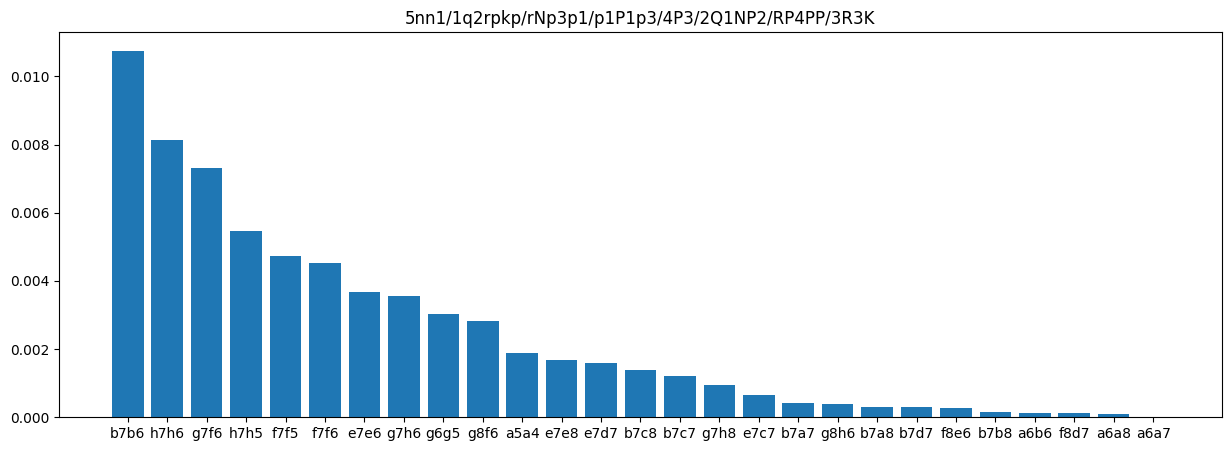

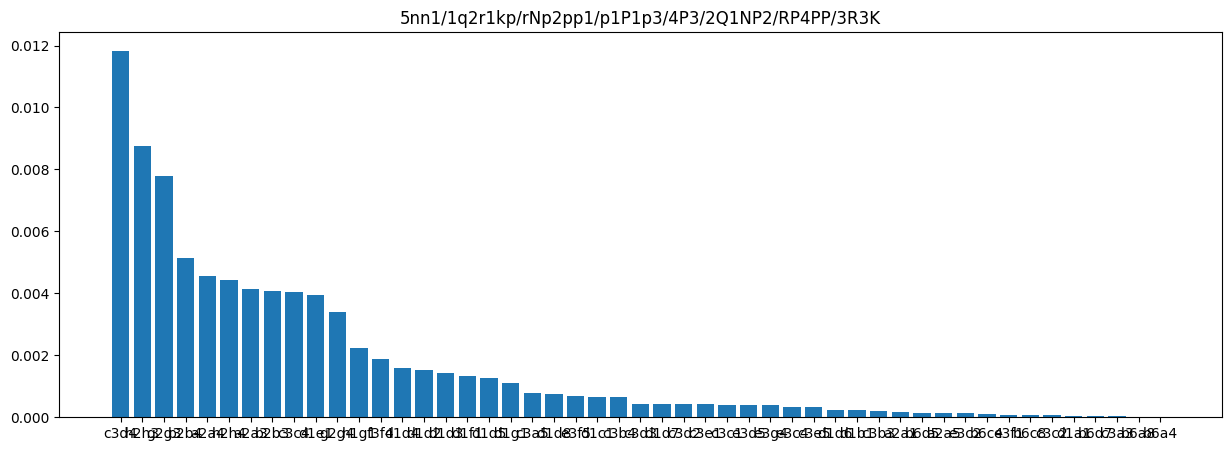

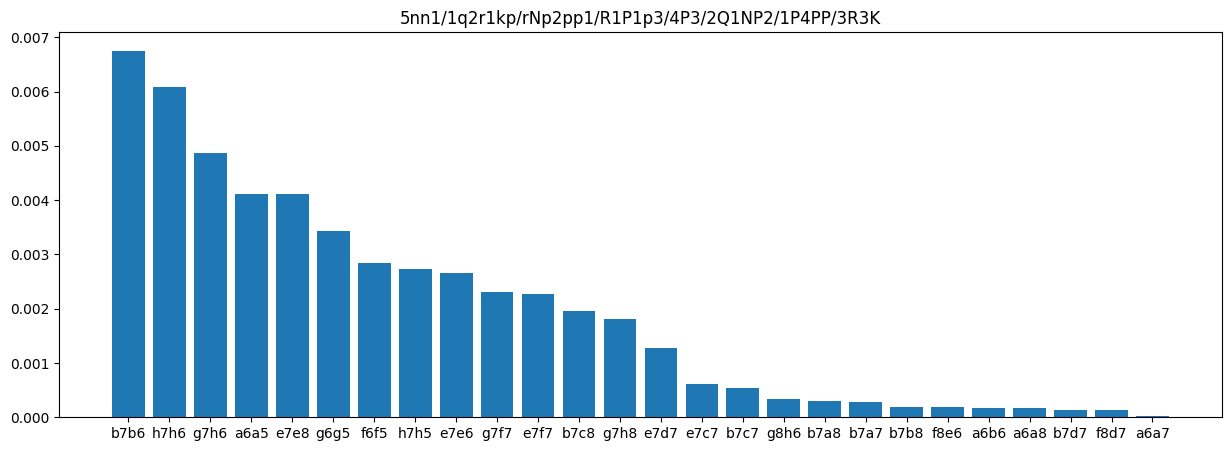

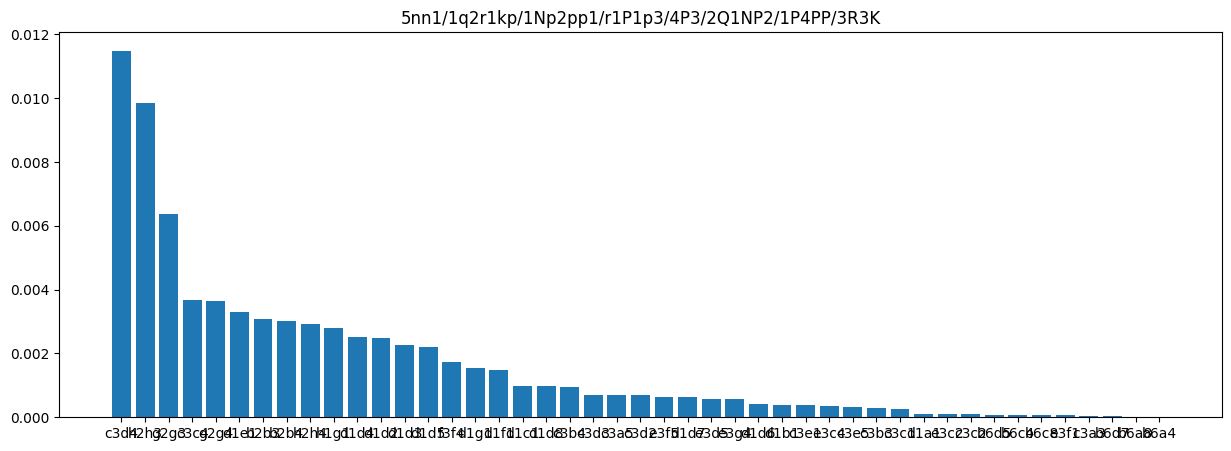

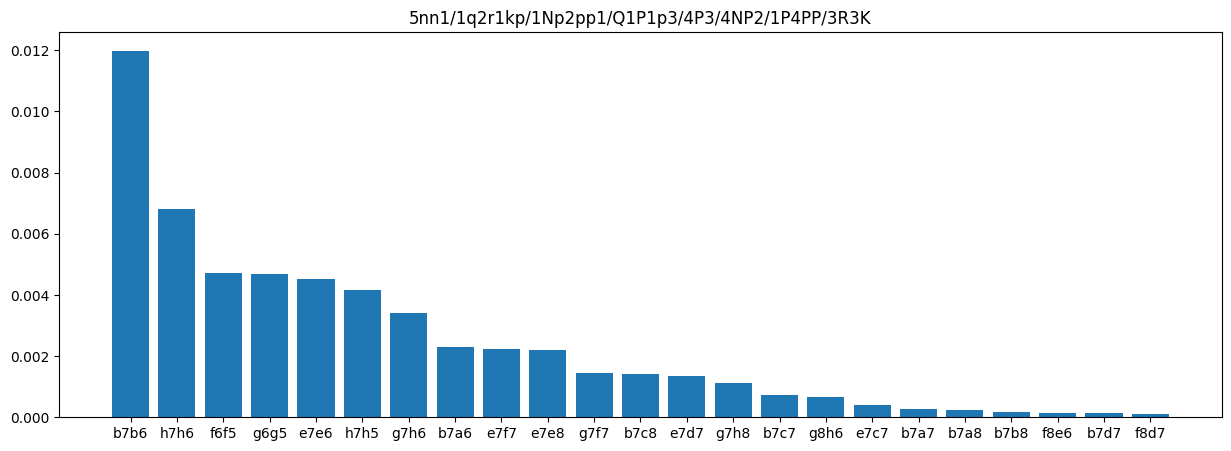

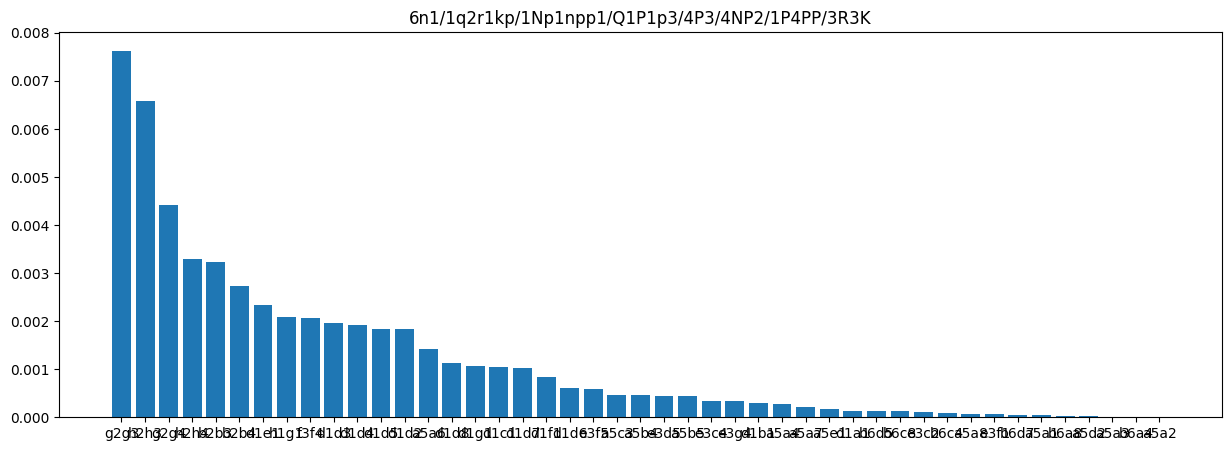

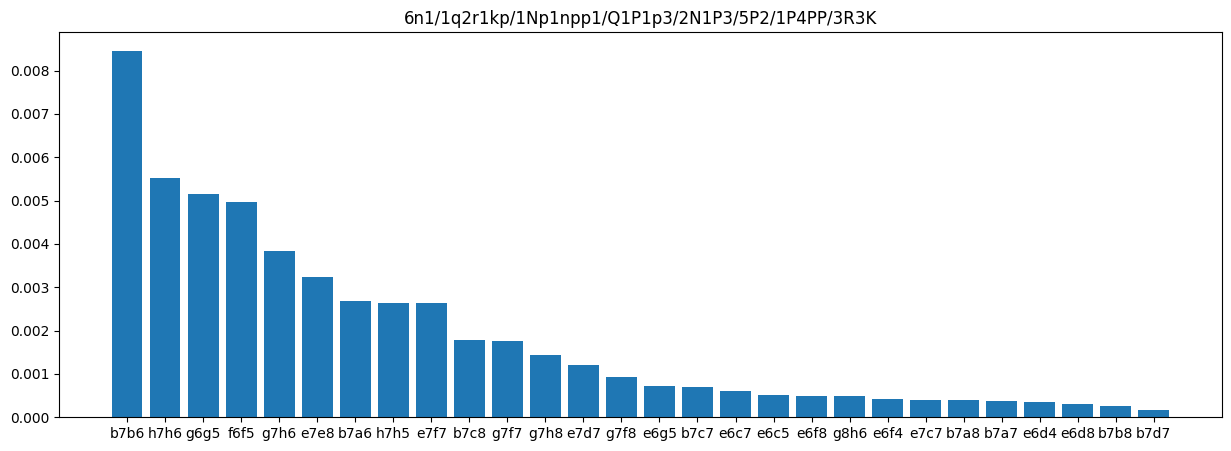

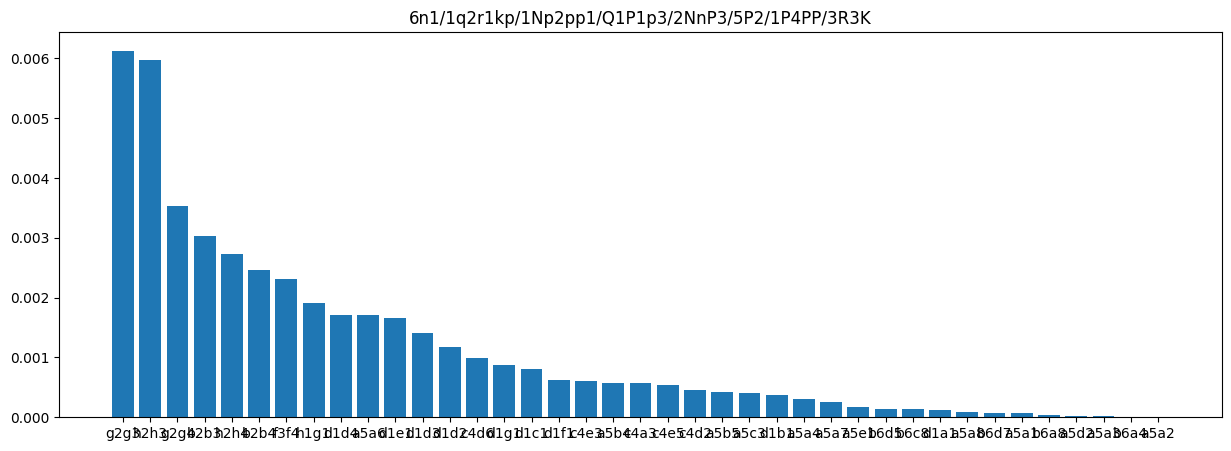

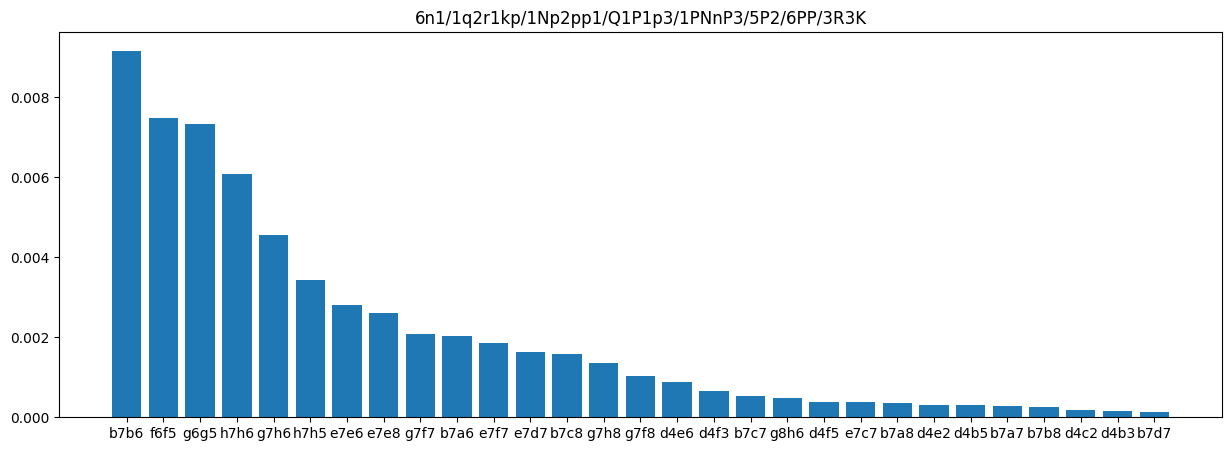

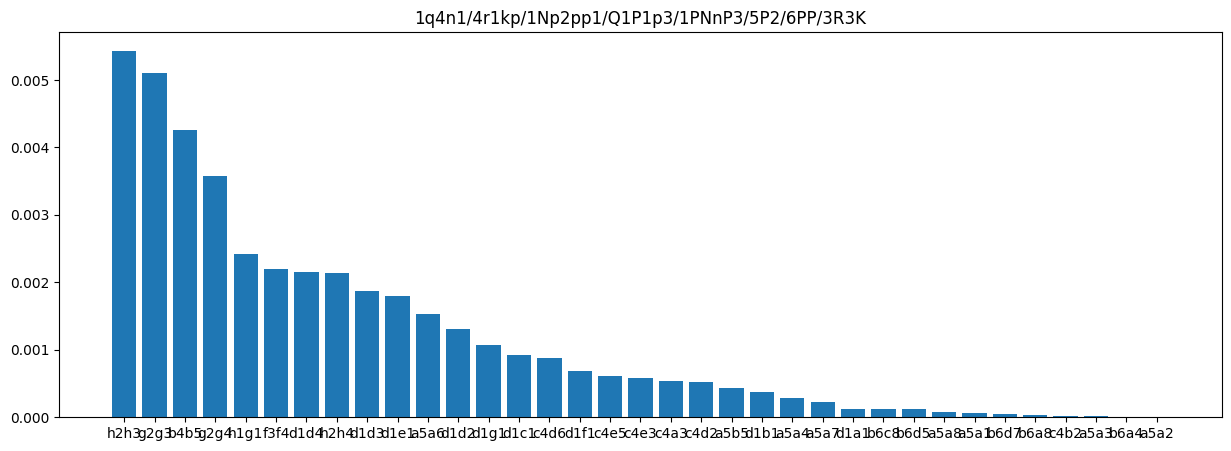

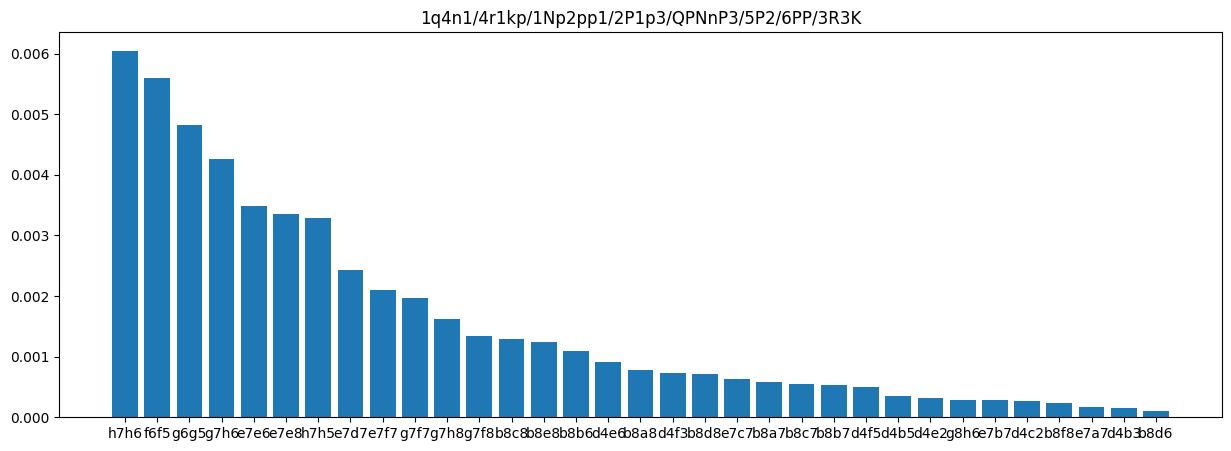

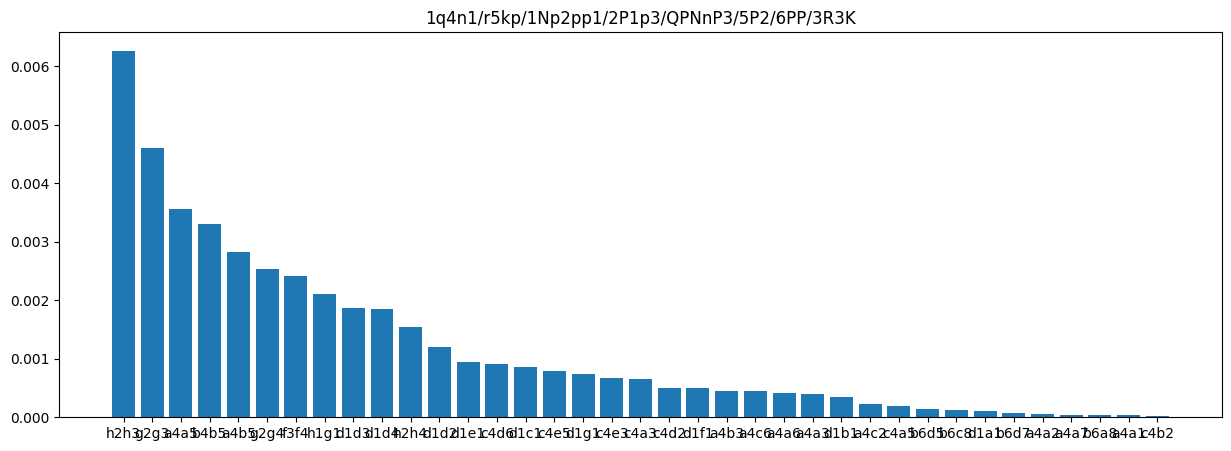

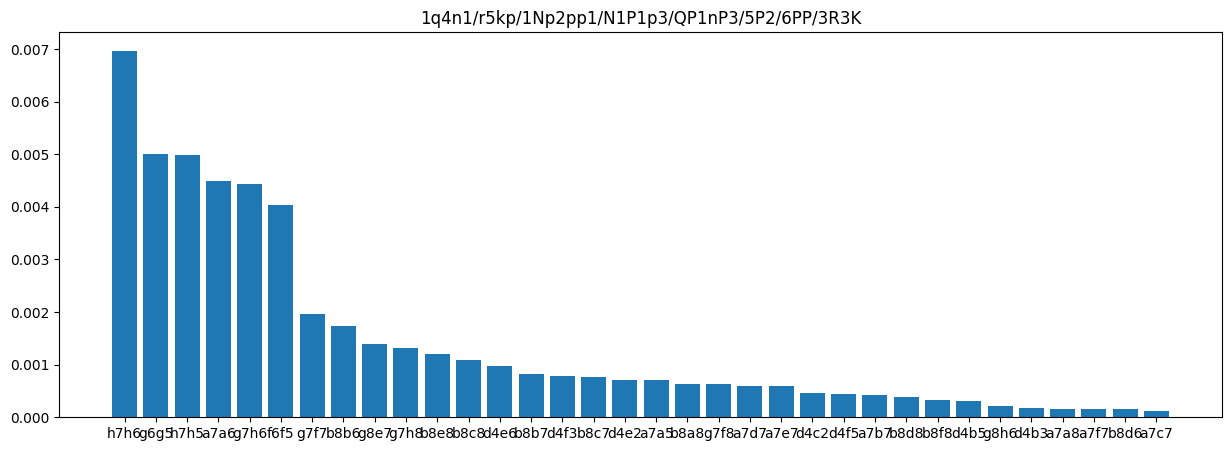

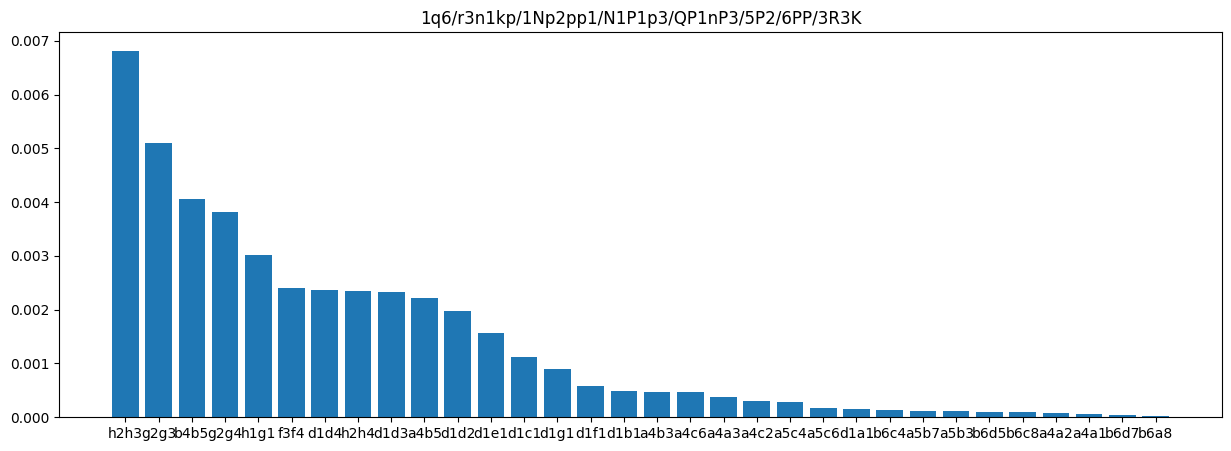

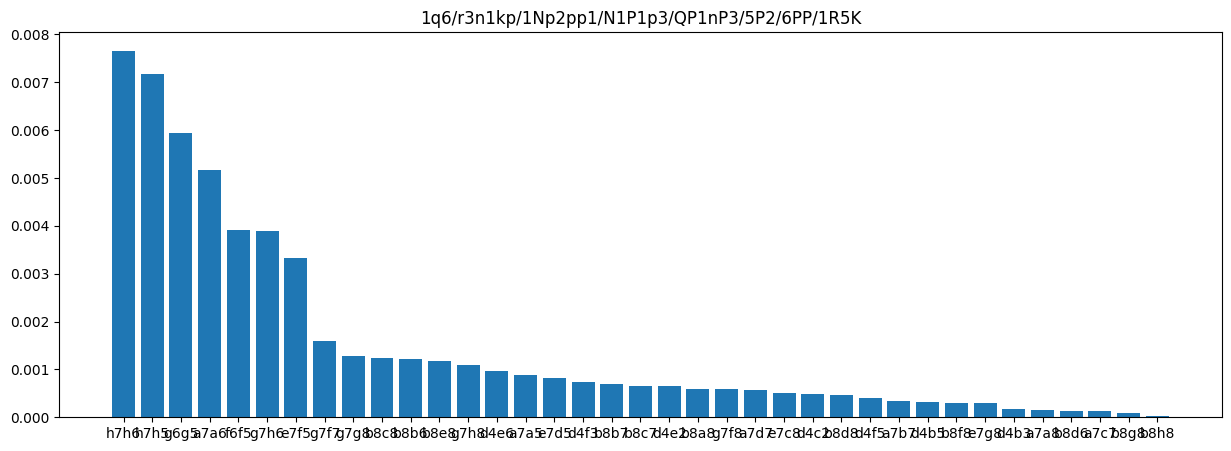

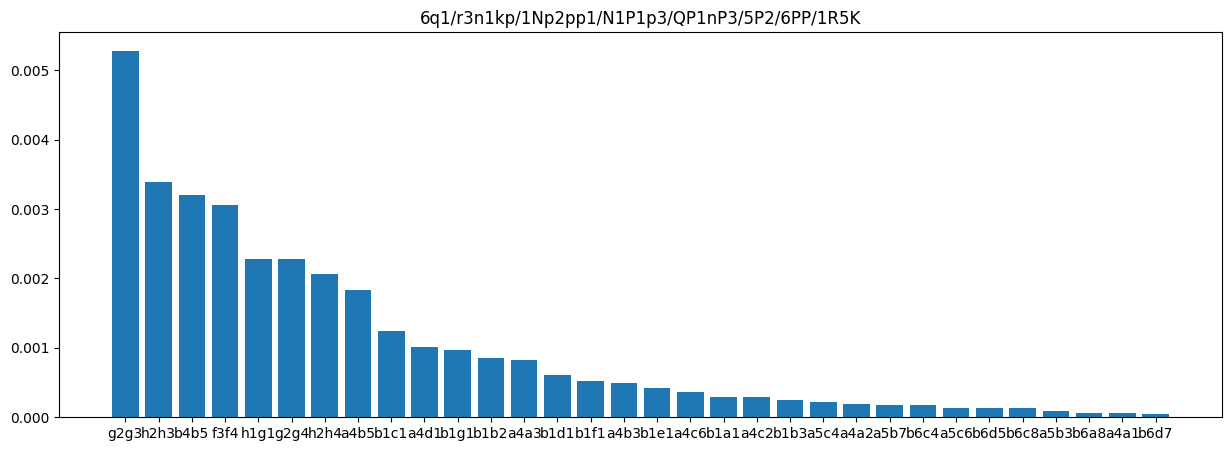

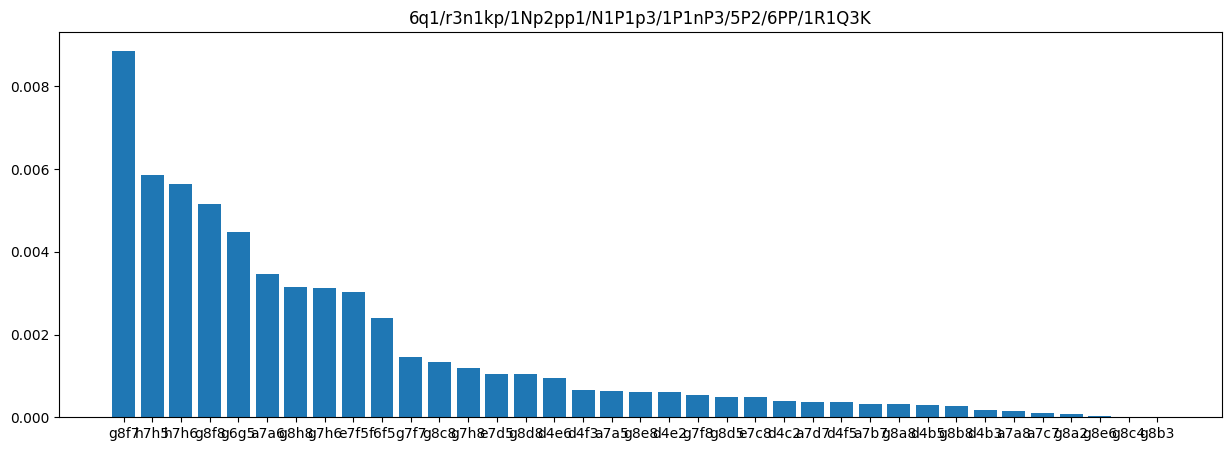

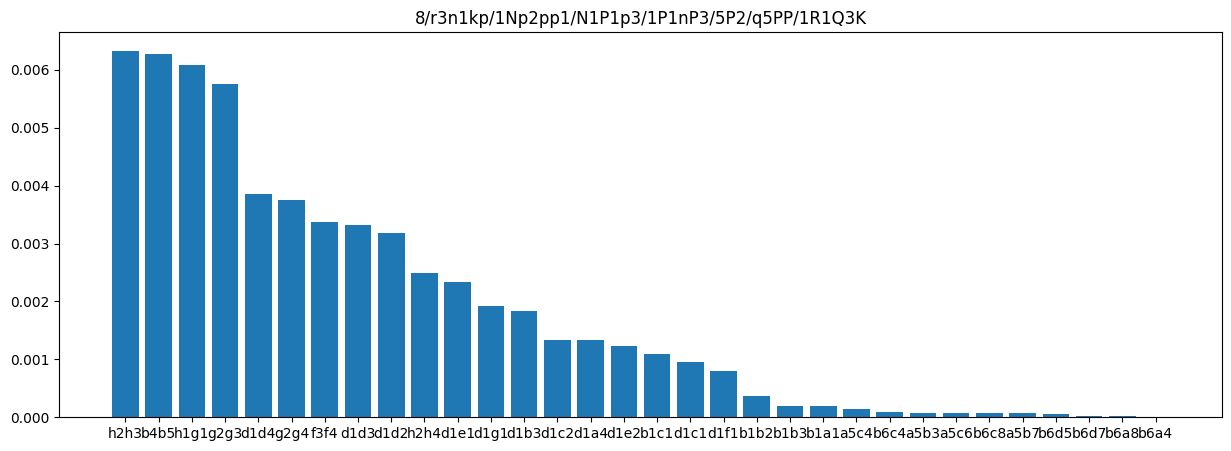

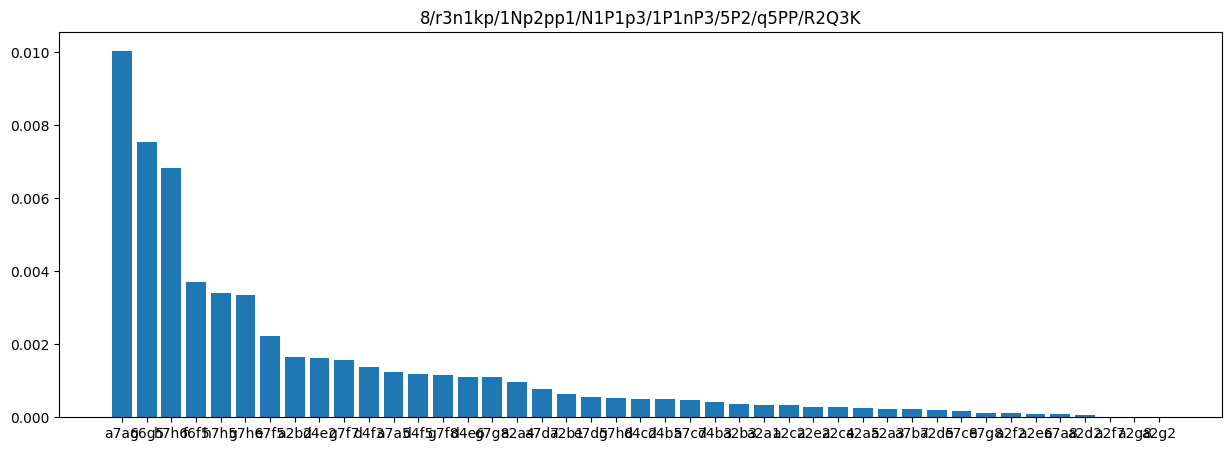

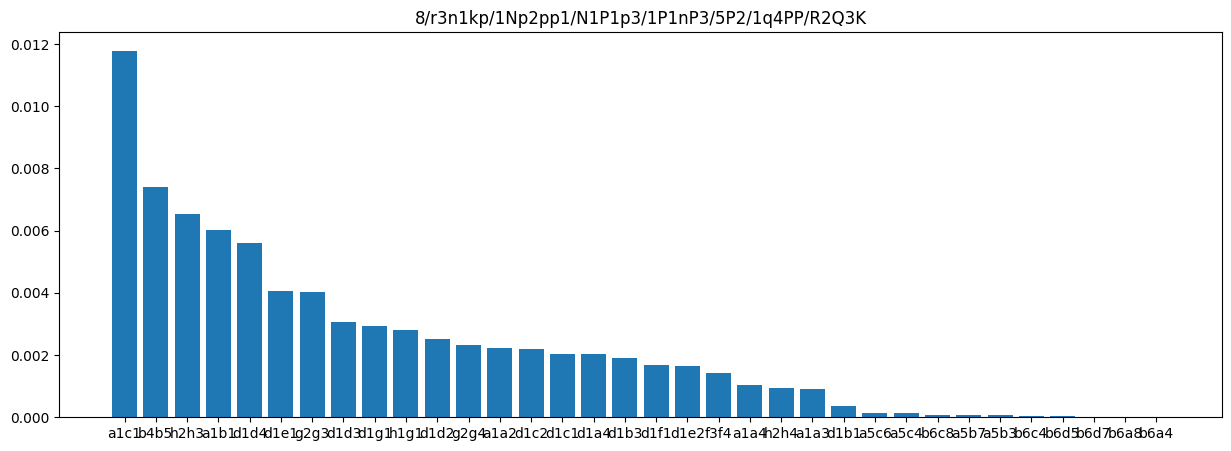

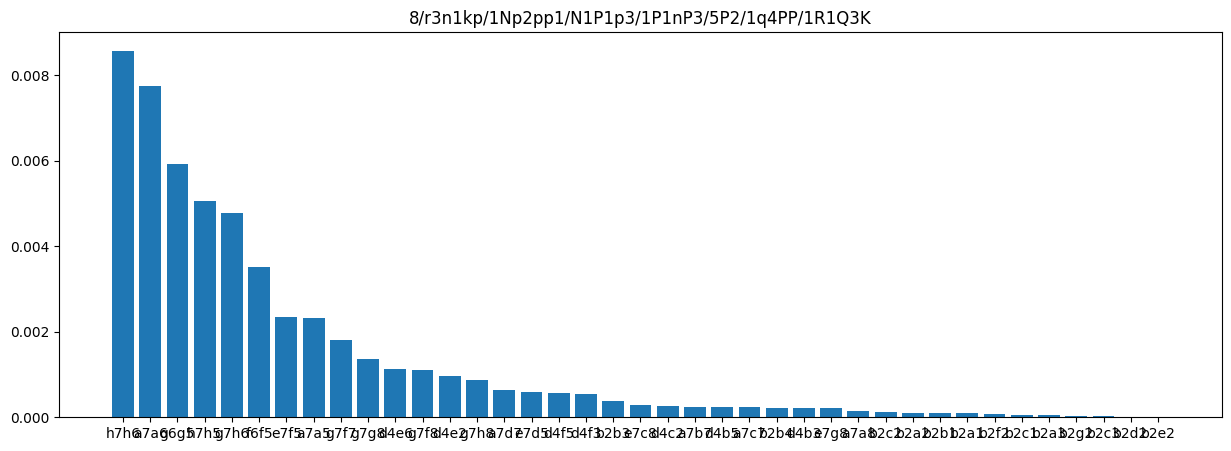

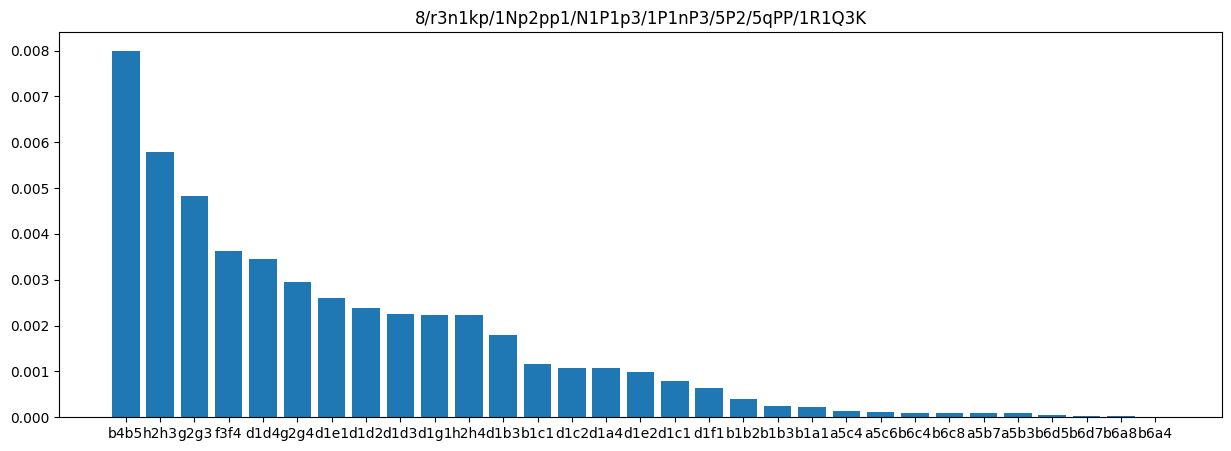

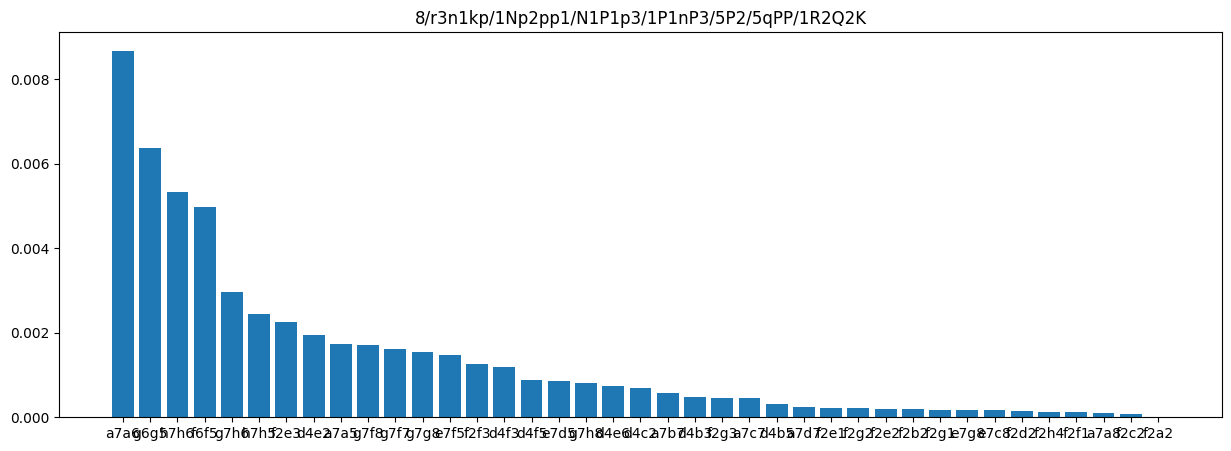

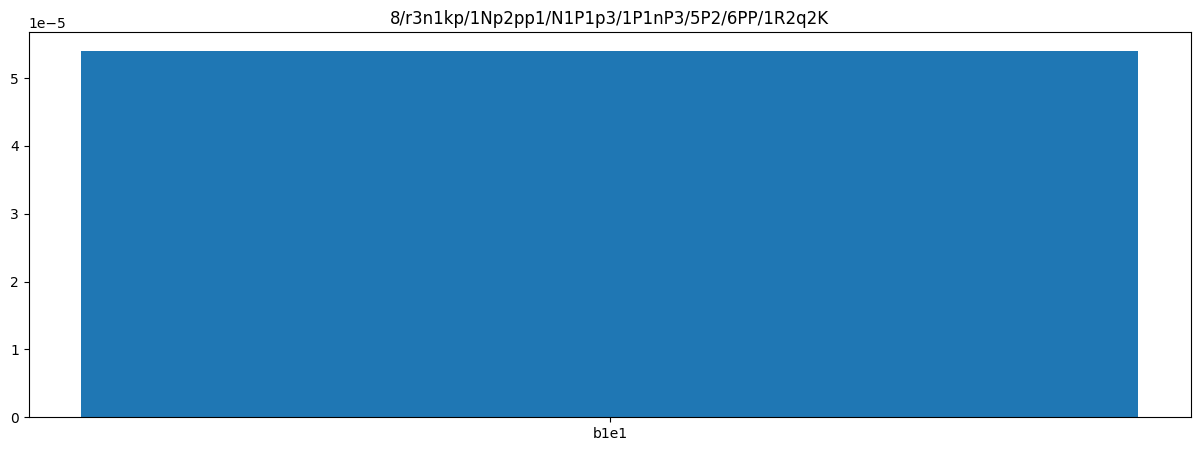

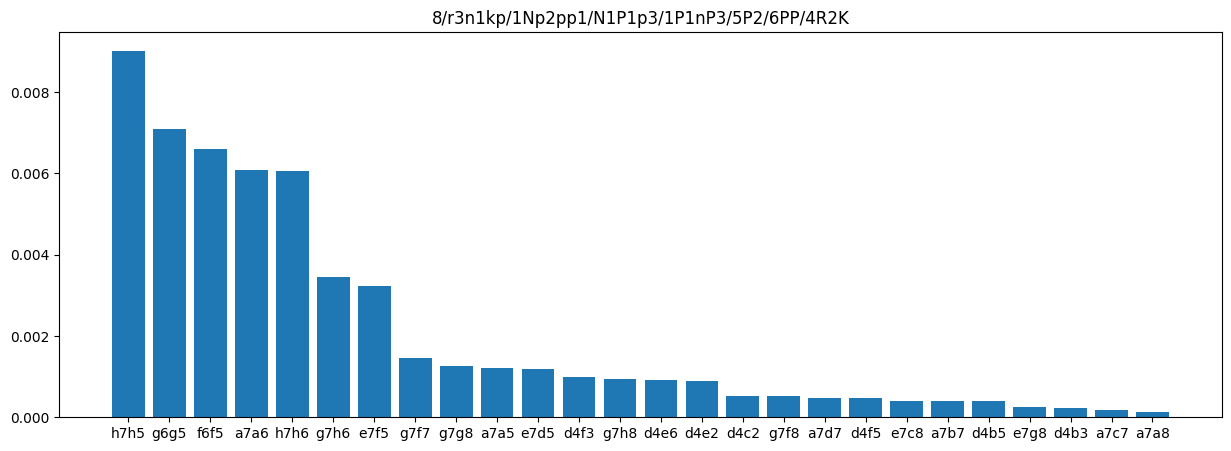

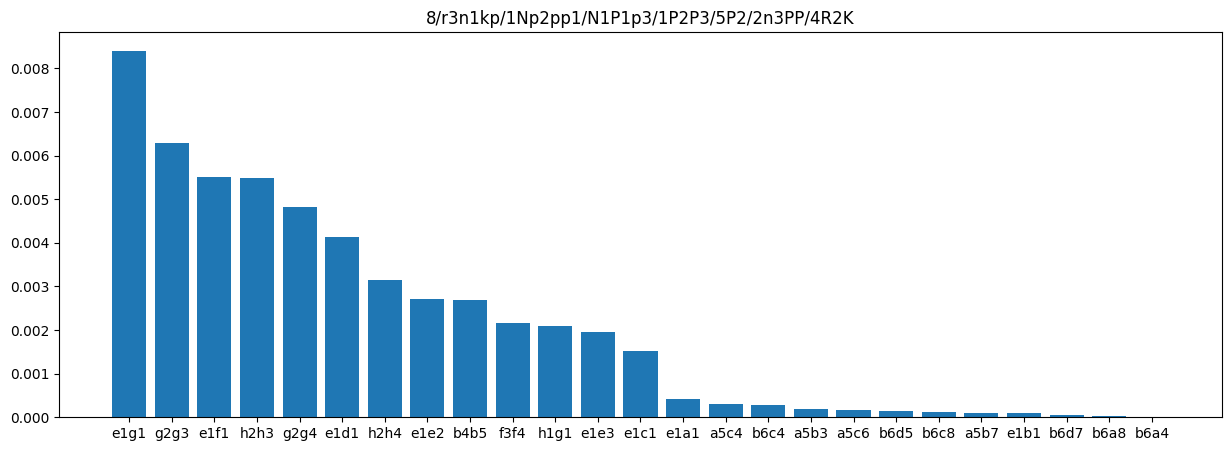

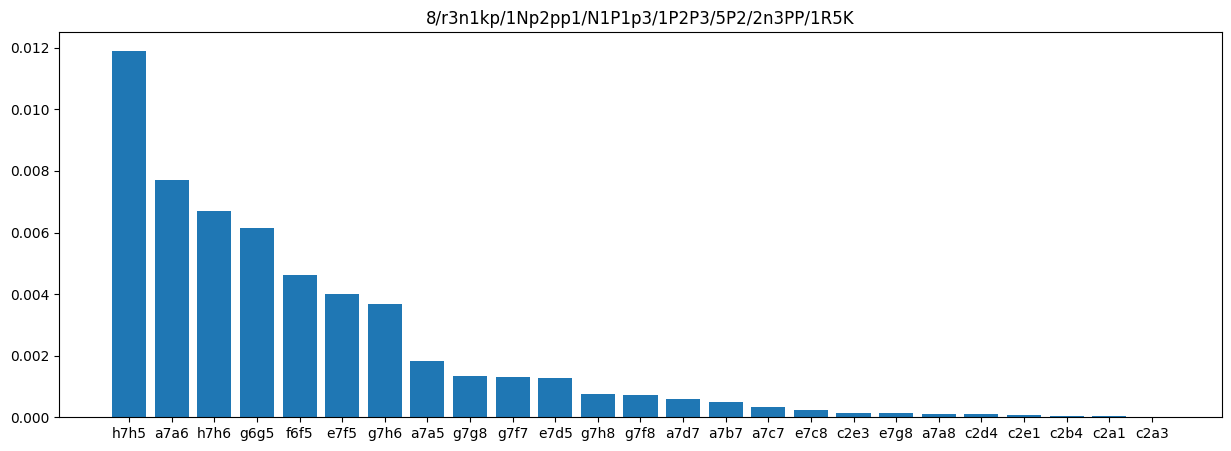

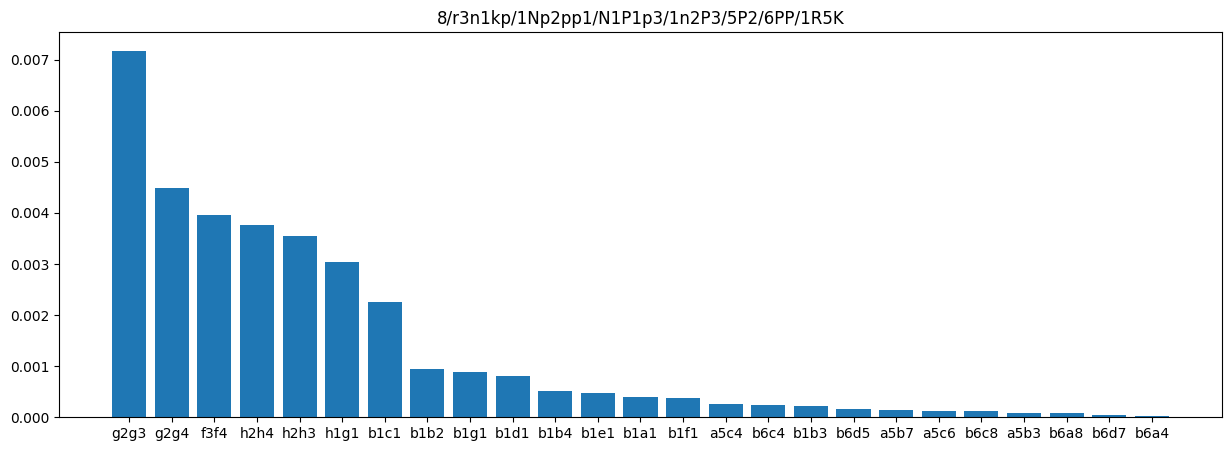

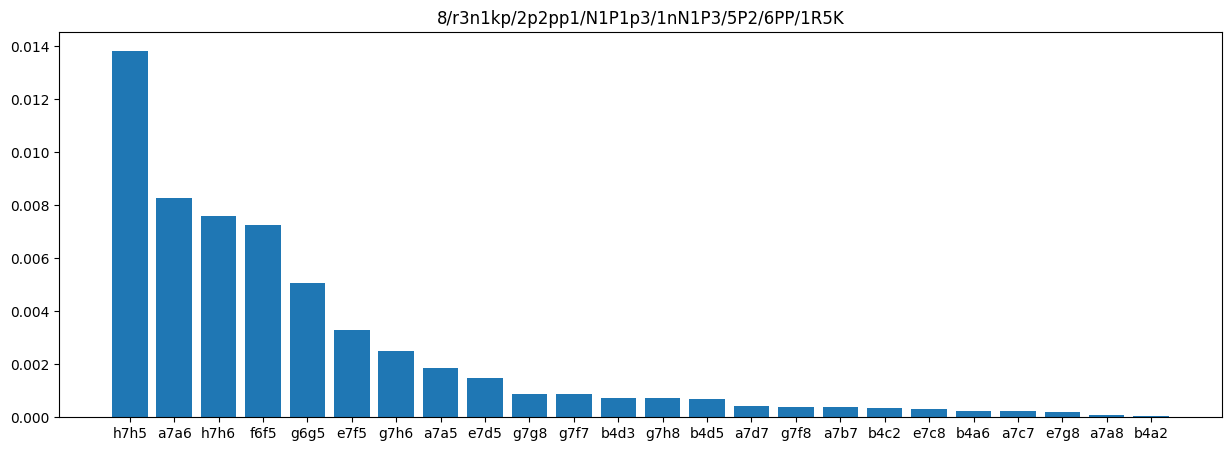

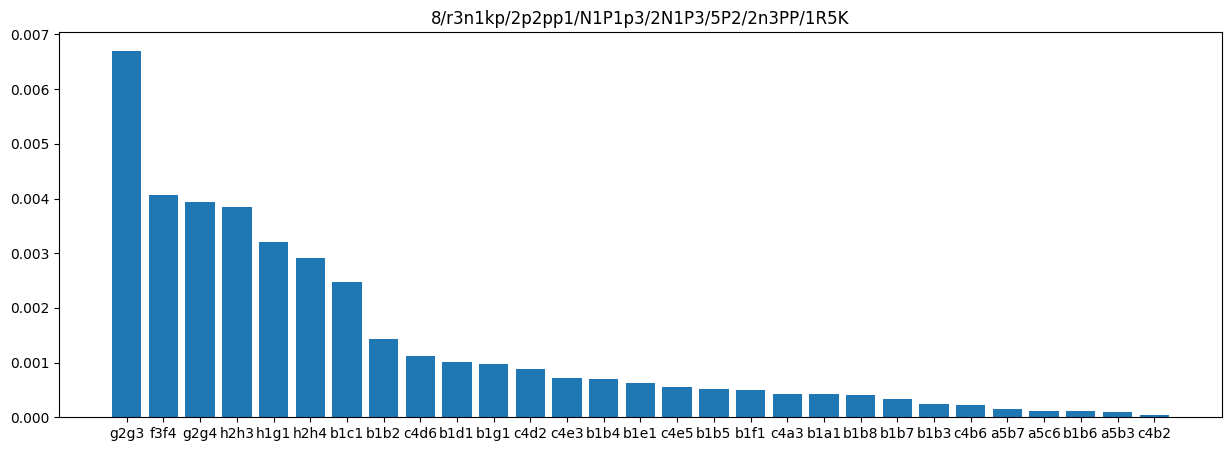

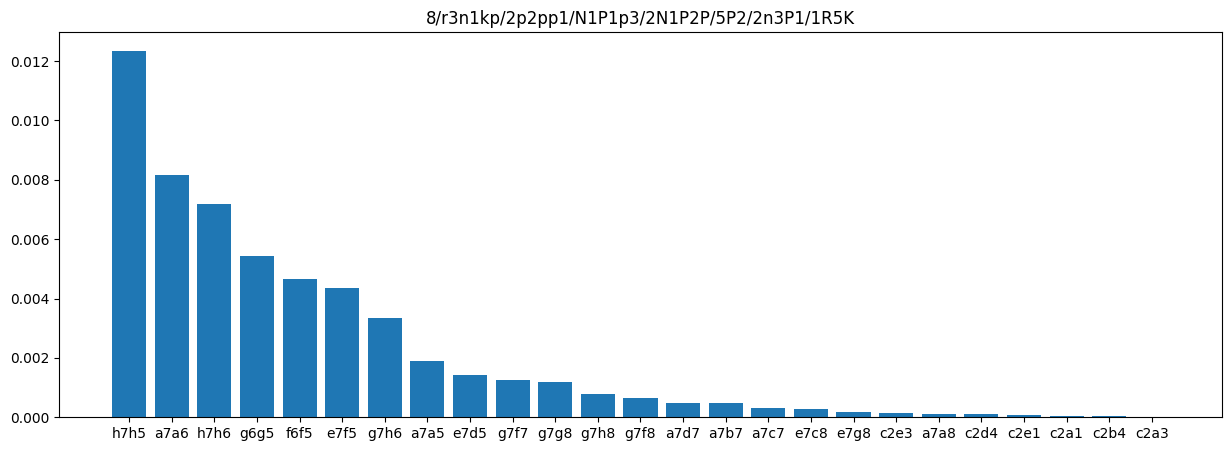

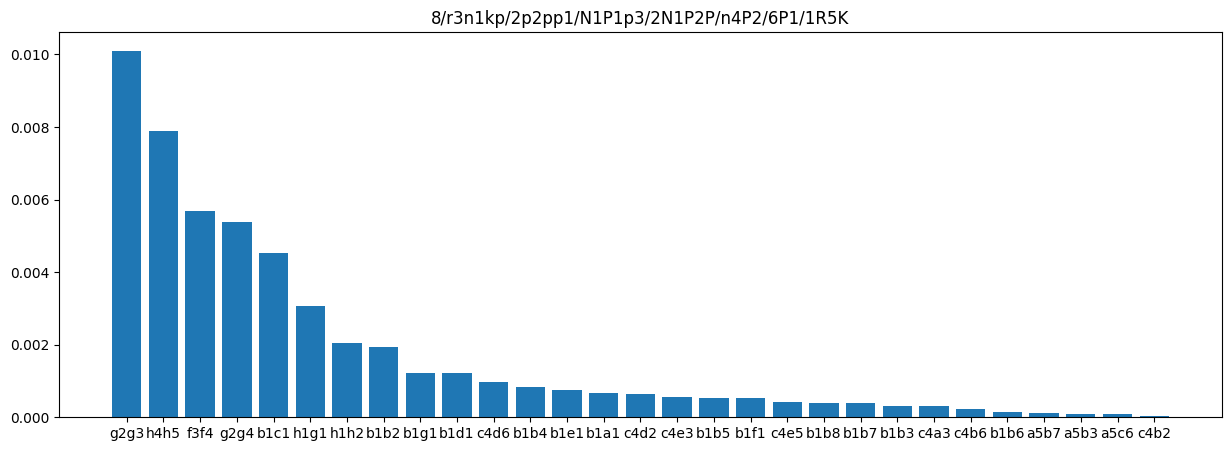

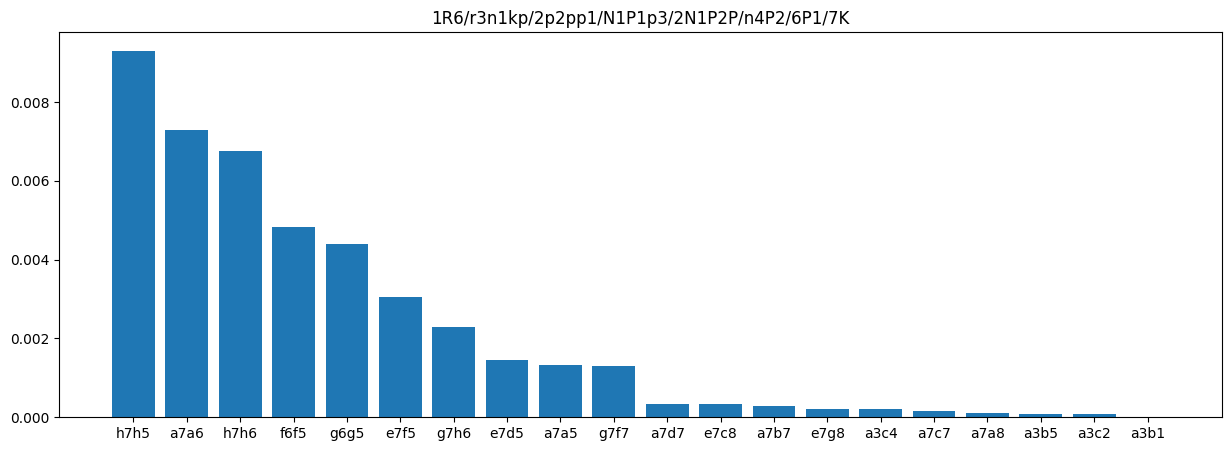

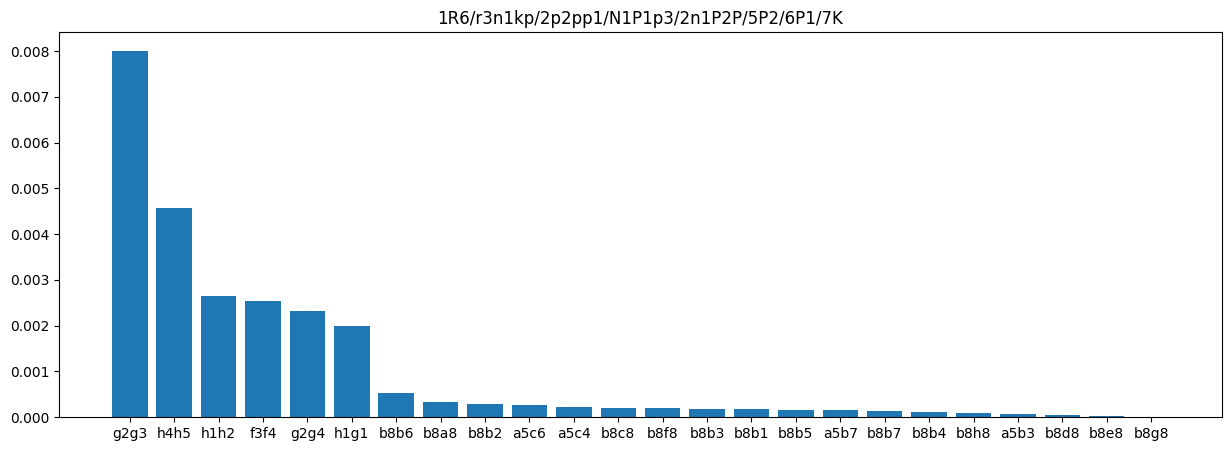

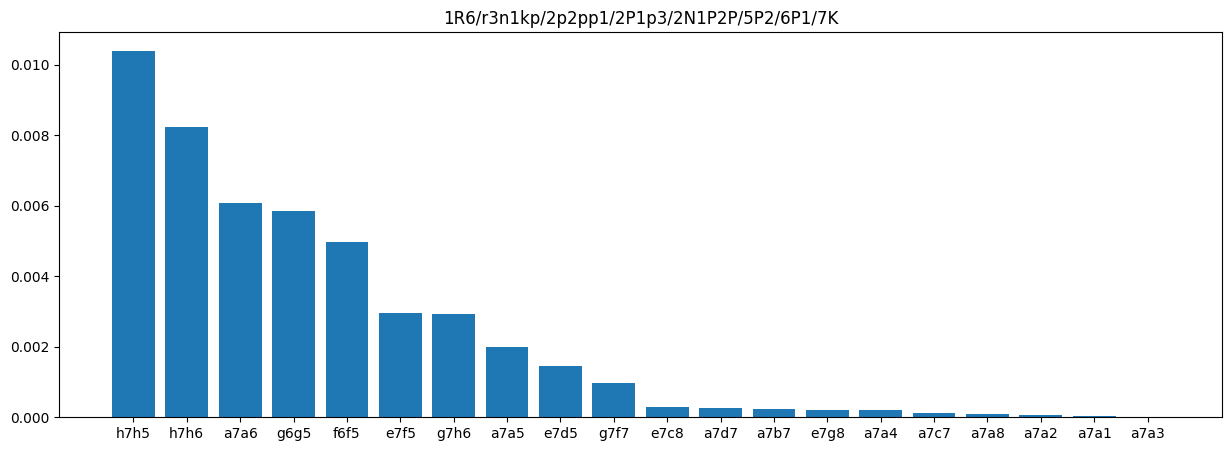

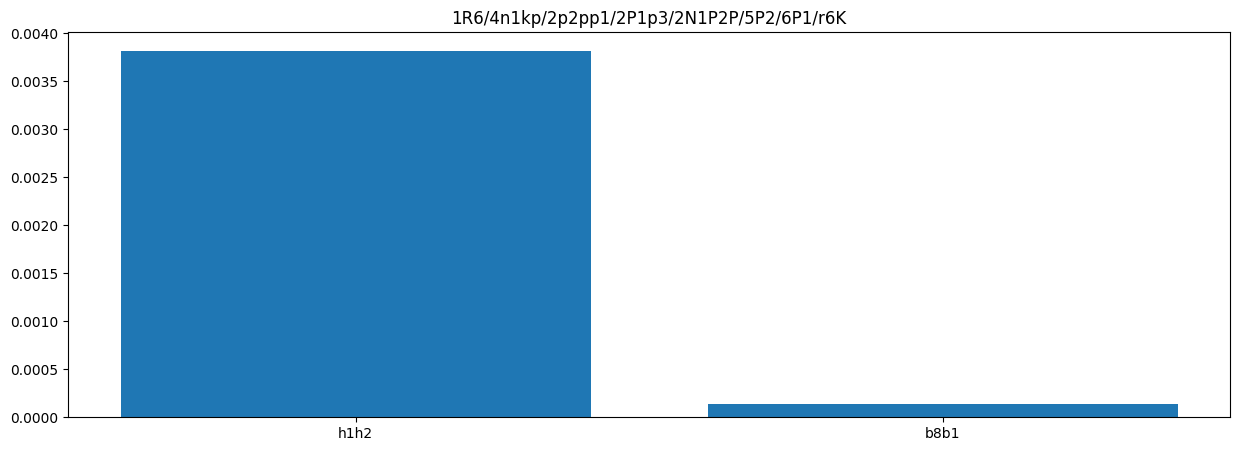

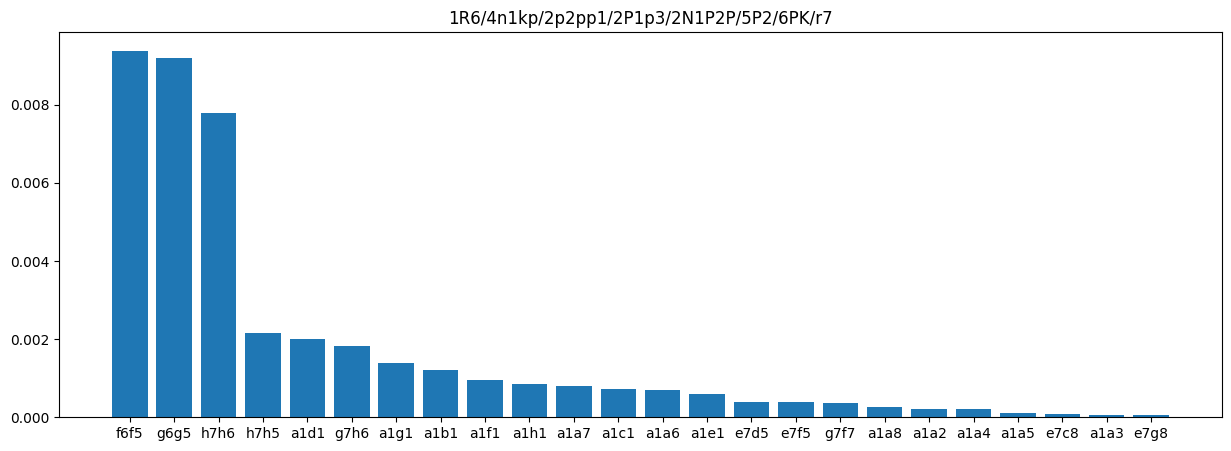

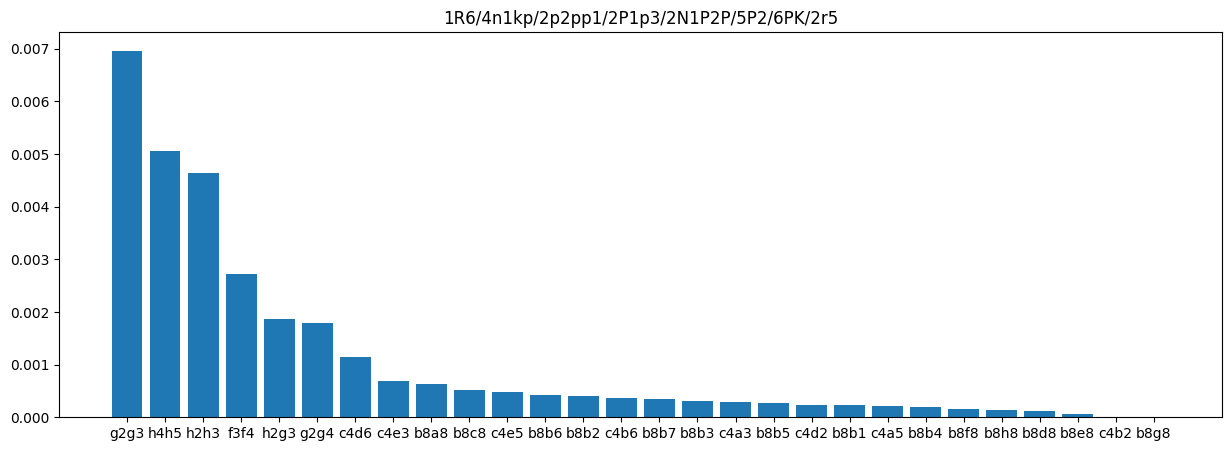

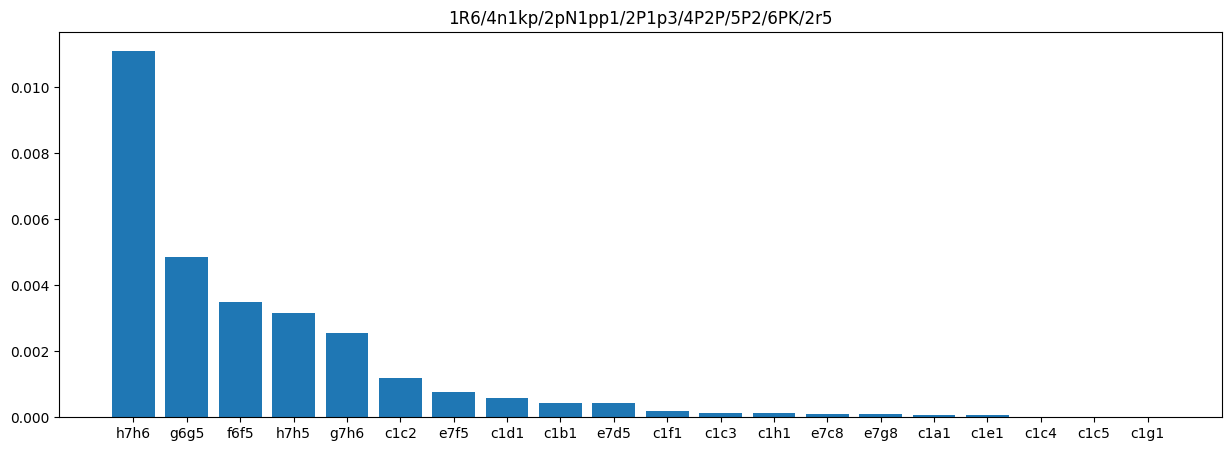

In [54]:
svgs = []

for i in range(100):
    print((deserialized:=State.deserialize((vector:=vectors[i]), mode="sequence")))
    fen = deserialized.split("<legal_moves>")[0]
    action = vector[vector.tolist().index(vectorize("<me>"))+2]
    prev_action = None
    if (op:=vectorize("<opponent>")) in vector:
        prev_action = vector[vector.tolist().index(op)+1]
    svg = anal(fen, i%2==0, prev_action, return_svg=True, ground_truth=action)
    svgs.append(svg)

In [55]:
from IPython.display import display, HTML
import ipywidgets as widgets

# Create next and previous buttons
prev_button = widgets.Button(description='Previous')
next_button = widgets.Button(description='Next')

# Create an output widget to display the SVG
output = widgets.Output()

# Keep track of current position
current_position = 0

# Define functions to update the display when buttons are clicked
def show_position(position):
    global current_position
    current_position = position
    with output:
        output.clear_output(wait=True)
        display(HTML(svgs[current_position]))
        
def on_prev_button_clicked(b):
    global current_position
    if current_position > 0:
        show_position(current_position - 1)
        
def on_next_button_clicked(b):
    global current_position
    if current_position < len(svgs) - 1:
        show_position(current_position + 1)

# Connect the functions to the buttons
prev_button.on_click(on_prev_button_clicked)
next_button.on_click(on_next_button_clicked)

# Display the initial SVG
show_position(0)

# Display the buttons and output widgets
display(widgets.HBox([prev_button, next_button]))
display(output)


Output()

In [58]:
len(svgs)

100